## 3D regression baseline (16-train / 16-test subset)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1.Set up the output folders for 3D experiment.

In [4]:
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose")
SPLIT_DIR = BASE_DIR / "data" / "splits"
CKPT_DIR = BASE_DIR / "outputs" / "checkpoints"
FIG_DIR = BASE_DIR / "outputs" / "figures" / "regression_3d_small"

CKPT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("SPLIT_DIR:", SPLIT_DIR)
print("CKPT_DIR :", CKPT_DIR)
print("FIG_DIR  :", FIG_DIR)

SPLIT_DIR: /content/drive/MyDrive/rectified_flow_ct2dose/data/splits
CKPT_DIR : /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints
FIG_DIR  : /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/regression_3d_small


### 2.Build a 3D manifest

In [5]:
import json
from pathlib import Path

DATA_ROOT = Path("/content/drive/MyDrive/rectified_flow_ct2dose/data/raw/46_53-32_cube/output")

case_dirs = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir()])
train_case_dirs = case_dirs[:8]
test_case_dirs = case_dirs[8:]

def build_3d_manifest(case_dirs):
    records = []
    for case_dir in case_dirs:
        input_dir = case_dir / "input_cubes"
        output_dir = case_dir / "output_cubes"

        input_files = sorted(input_dir.glob("*.npy"))
        for input_path in input_files:
            output_path = output_dir / input_path.name
            if output_path.exists():
                records.append({
                    "case_id": case_dir.name,
                    "input_path": str(input_path),
                    "output_path": str(output_path),
                })
    return records

train_records_3d = build_3d_manifest(train_case_dirs)
test_records_3d = build_3d_manifest(test_case_dirs)

with open(SPLIT_DIR / "train_pairs_3d.json", "w", encoding="utf-8") as f:
    json.dump(train_records_3d, f, indent=2)

with open(SPLIT_DIR / "test_pairs_3d.json", "w", encoding="utf-8") as f:
    json.dump(test_records_3d, f, indent=2)

print("Train 3D samples:", len(train_records_3d))
print("Test 3D samples :", len(test_records_3d))
print("Saved:", SPLIT_DIR / "train_pairs_3d.json")
print("Saved:", SPLIT_DIR / "test_pairs_3d.json")

Train 3D samples: 16000
Test 3D samples : 4000
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/data/splits/train_pairs_3d.json
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/data/splits/test_pairs_3d.json


### 3.Define a 3D dataset

In [6]:
import json
import numpy as np
import torch
from torch.utils.data import Dataset

def normalize_ct(x):
    x = np.clip(x, -1024.0, 1500.0)
    x = (x + 1024.0) / (1500.0 + 1024.0)
    return x.astype(np.float32)

class CubePair3DDataset(Dataset):
    def __init__(self, manifest_path, dose_scale=1000.0):
        with open(manifest_path, "r", encoding="utf-8") as f:
            self.records = json.load(f)
        self.dose_scale = dose_scale

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        x0 = np.load(rec["input_path"]).astype(np.float32)   # (32,32,32)
        x1 = np.load(rec["output_path"]).astype(np.float32)  # (32,32,32)

        x0 = normalize_ct(x0)
        x1 = (x1 * self.dose_scale).astype(np.float32)

        x0 = torch.from_numpy(x0).unsqueeze(0)   # (1,D,H,W)
        x1 = torch.from_numpy(x1).unsqueeze(0)   # (1,D,H,W)

        return x0, x1

### 4.Test 3D Dataset and DataLoader

In [7]:
from pathlib import Path
from torch.utils.data import DataLoader, Subset

train_manifest_3d = SPLIT_DIR / "train_pairs_3d.json"
test_manifest_3d  = SPLIT_DIR / "test_pairs_3d.json"

train_dataset_3d = CubePair3DDataset(train_manifest_3d, dose_scale=1000.0)
test_dataset_3d  = CubePair3DDataset(test_manifest_3d, dose_scale=1000.0)

small_train_3d = Subset(train_dataset_3d, list(range(16)))
small_test_3d  = Subset(test_dataset_3d, list(range(16)))

train_loader_3d = DataLoader(small_train_3d, batch_size=2, shuffle=True, num_workers=0)
test_loader_3d  = DataLoader(small_test_3d, batch_size=2, shuffle=False, num_workers=0)

x0, x1 = small_train_3d[0]
print("Single sample x0:", x0.shape, x0.dtype, x0.min().item(), x0.max().item())
print("Single sample x1:", x1.shape, x1.dtype, x1.min().item(), x1.max().item())

bx0, bx1 = next(iter(train_loader_3d))
print("Batch x0:", bx0.shape, bx0.dtype)
print("Batch x1:", bx1.shape, bx1.dtype)

Single sample x0: torch.Size([1, 32, 32, 32]) torch.float32 0.0033760373480618 0.8727859258651733
Single sample x1: torch.Size([1, 32, 32, 32]) torch.float32 0.0007880193879827857 2.7264456748962402
Batch x0: torch.Size([2, 1, 32, 32, 32]) torch.float32
Batch x1: torch.Size([2, 1, 32, 32, 32]) torch.float32


### 5.Define Minimal 3D U-Net

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class UNet3D(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base_ch=16):
        super().__init__()

        self.enc1 = DoubleConv3D(in_ch, base_ch)
        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv3D(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv3D(base_ch * 2, base_ch * 4)

        self.up2 = nn.ConvTranspose3d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose3d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(base_ch * 2, base_ch)

        self.out_conv = nn.Conv3d(base_ch, out_ch, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)

### 6.Training Setup

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model_3d = UNet3D(in_ch=1, out_ch=1, base_ch=16).to(device)
optimizer = torch.optim.Adam(model_3d.parameters(), lr=1e-3)

def regression_loss_3d(model, x0, x1):
    pred = model(x0)
    loss = F.mse_loss(pred, x1)
    return loss, pred

device: cuda


### 7.Train 3D Baseline

In [10]:
num_epochs = 20
train_losses_3d = []

for epoch in range(num_epochs):
    model_3d.train()
    running_loss = 0.0

    for x0, x1 in train_loader_3d:
        x0 = x0.to(device)
        x1 = x1.to(device)

        optimizer.zero_grad()
        loss, pred = regression_loss_3d(model_3d, x0, x1)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader_3d)
    train_losses_3d.append(epoch_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - train loss: {epoch_loss:.6f}")

Epoch 1/20 - train loss: 0.005769
Epoch 2/20 - train loss: 0.004358
Epoch 3/20 - train loss: 0.004117
Epoch 4/20 - train loss: 0.003567
Epoch 5/20 - train loss: 0.002942
Epoch 6/20 - train loss: 0.002455
Epoch 7/20 - train loss: 0.002268
Epoch 8/20 - train loss: 0.002030
Epoch 9/20 - train loss: 0.002116
Epoch 10/20 - train loss: 0.002328
Epoch 11/20 - train loss: 0.001947
Epoch 12/20 - train loss: 0.001553
Epoch 13/20 - train loss: 0.001398
Epoch 14/20 - train loss: 0.001421
Epoch 15/20 - train loss: 0.001182
Epoch 16/20 - train loss: 0.001171
Epoch 17/20 - train loss: 0.000956
Epoch 18/20 - train loss: 0.000876
Epoch 19/20 - train loss: 0.000873
Epoch 20/20 - train loss: 0.000879


### 8.Save Loss Curve

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/regression_3d_small/loss_curve.png


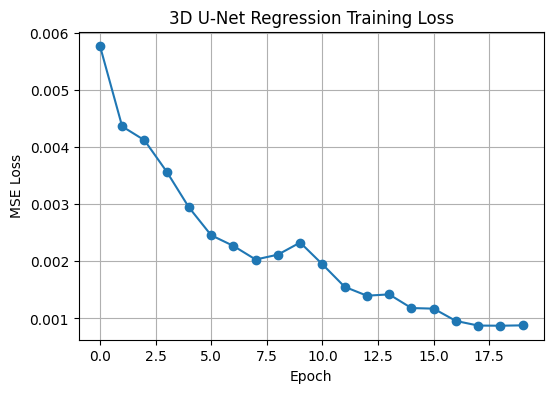

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(train_losses_3d, marker="o")
ax.set_title("3D U-Net Regression Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.grid(True)

fig.savefig(FIG_DIR / "loss_curve.png", dpi=150, bbox_inches="tight")
print("Saved:", FIG_DIR / "loss_curve.png")
plt.show()

### 9.Evaluate Average Metrics for Train/Test Sets

In [12]:
@torch.no_grad()
def evaluate_regression_3d(model, loader, device):
    model.eval()
    total_mse = 0.0
    total_mae = 0.0
    n_batches = 0

    for x0, x1 in loader:
        x0 = x0.to(device)
        x1 = x1.to(device)

        pred = model(x0)

        mse = F.mse_loss(pred, x1).item()
        mae = F.l1_loss(pred, x1).item()

        total_mse += mse
        total_mae += mae
        n_batches += 1

    return {
        "mse": total_mse / n_batches,
        "mae": total_mae / n_batches
    }

train_metrics_3d = evaluate_regression_3d(model_3d, train_loader_3d, device)
test_metrics_3d  = evaluate_regression_3d(model_3d, test_loader_3d, device)

print("Train metrics 3D:", train_metrics_3d)
print("Test metrics 3D :", test_metrics_3d)

Train metrics 3D: {'mse': 0.0008608824718976393, 'mae': 0.012464097468182445}
Test metrics 3D : {'mse': 0.0009229695788235404, 'mae': 0.013821591390296817}


### 10.Save Middle Slice Plots for Train/Test Sets

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/regression_3d_small/train_examples.png


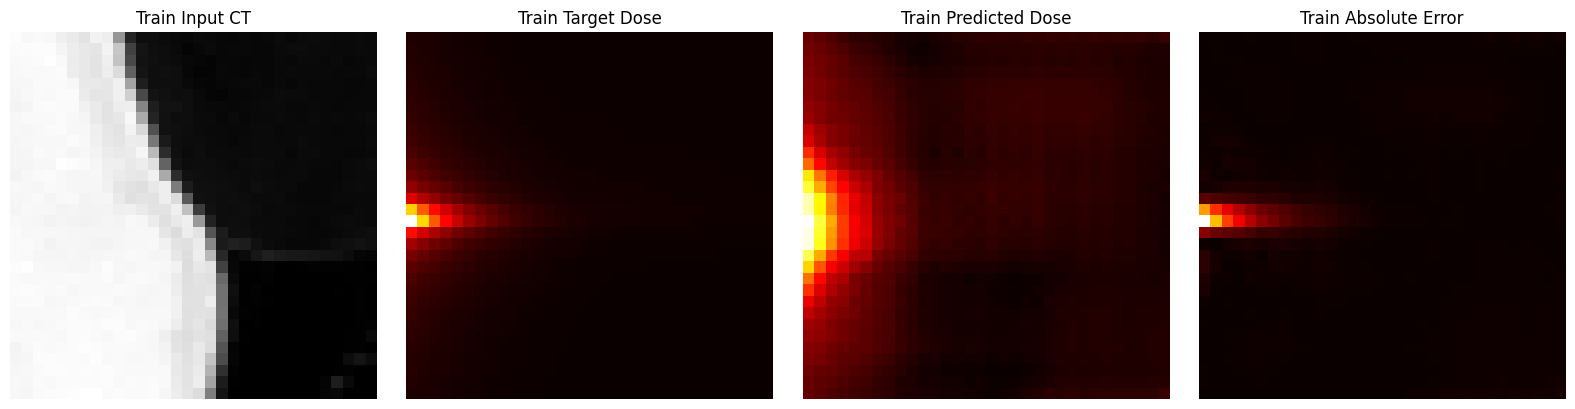

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/regression_3d_small/test_examples.png


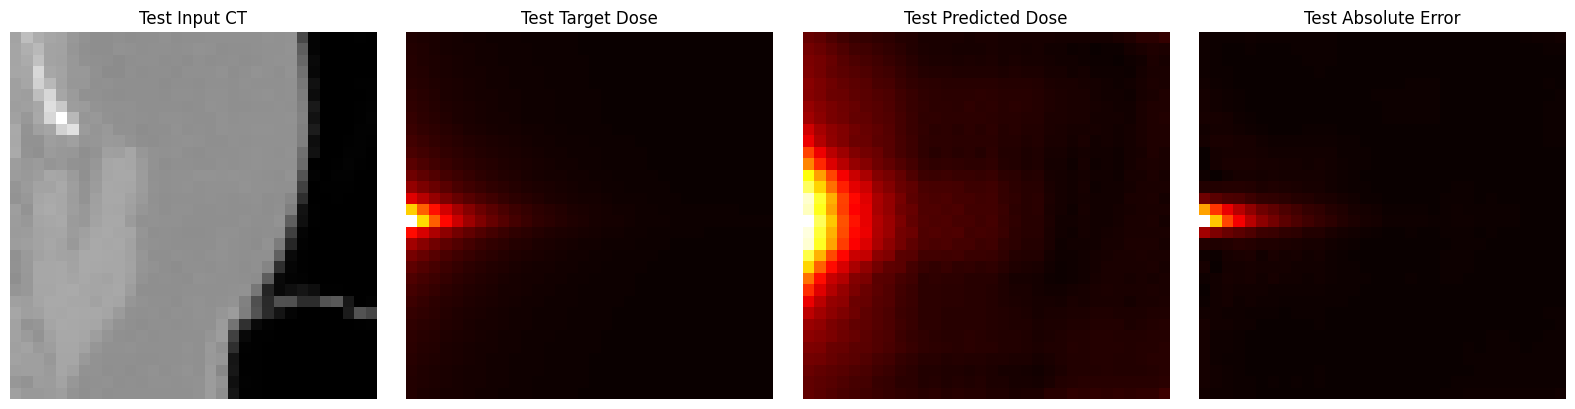

In [13]:
import numpy as np
import matplotlib.pyplot as plt

model_3d.eval()

# train example
x0, x1 = next(iter(train_loader_3d))
x0 = x0.to(device)
x1 = x1.to(device)

with torch.no_grad():
    pred = model_3d(x0)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()
mid = x0_np.shape[0] // 2

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(x0_np[mid], cmap="gray")
axes[0].set_title("Train Input CT")
axes[0].axis("off")

axes[1].imshow(x1_np[mid], cmap="hot")
axes[1].set_title("Train Target Dose")
axes[1].axis("off")

axes[2].imshow(pred_np[mid], cmap="hot")
axes[2].set_title("Train Predicted Dose")
axes[2].axis("off")

axes[3].imshow(np.abs(pred_np[mid] - x1_np[mid]), cmap="hot")
axes[3].set_title("Train Absolute Error")
axes[3].axis("off")

plt.tight_layout()
fig.savefig(FIG_DIR / "train_examples.png", dpi=150, bbox_inches="tight")
print("Saved:", FIG_DIR / "train_examples.png")
plt.show()


# test example
x0, x1 = next(iter(test_loader_3d))
x0 = x0.to(device)
x1 = x1.to(device)

with torch.no_grad():
    pred = model_3d(x0)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()
mid = x0_np.shape[0] // 2

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(x0_np[mid], cmap="gray")
axes[0].set_title("Test Input CT")
axes[0].axis("off")

axes[1].imshow(x1_np[mid], cmap="hot")
axes[1].set_title("Test Target Dose")
axes[1].axis("off")

axes[2].imshow(pred_np[mid], cmap="hot")
axes[2].set_title("Test Predicted Dose")
axes[2].axis("off")

axes[3].imshow(np.abs(pred_np[mid] - x1_np[mid]), cmap="hot")
axes[3].set_title("Test Absolute Error")
axes[3].axis("off")

plt.tight_layout()
fig.savefig(FIG_DIR / "test_examples.png", dpi=150, bbox_inches="tight")
print("Saved:", FIG_DIR / "test_examples.png")
plt.show()

### 11.Save checkpoint

In [14]:
ckpt_path = CKPT_DIR / "unet3d_regression_small.pt"

torch.save({
    "model_state_dict": model_3d.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses": train_losses_3d,
    "train_metrics": train_metrics_3d,
    "test_metrics": test_metrics_3d,
    "dose_scale": 1000.0,
    "num_epochs": num_epochs,
    "num_train_samples": 16,
    "num_test_samples": 16,
}, ckpt_path)

print("Saved checkpoint to:", ckpt_path)

Saved checkpoint to: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/unet3d_regression_small.pt


## 3D regression baseline (32-train / 16-test subset)

### 1.Imports

In [15]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

### 2.Set seed

In [16]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

### 3.Paths

In [17]:
BASE_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose")
DATA_ROOT = BASE_DIR / "data" / "raw" / "46_53-32_cube" / "output"
SPLIT_DIR = BASE_DIR / "data" / "splits"
CKPT_DIR = BASE_DIR / "outputs" / "checkpoints"
FIG_DIR = BASE_DIR / "outputs" / "figures" / "regression_3d_32samples"

SPLIT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("SPLIT_DIR:", SPLIT_DIR)
print("CKPT_DIR :", CKPT_DIR)
print("FIG_DIR  :", FIG_DIR)

DATA_ROOT: /content/drive/MyDrive/rectified_flow_ct2dose/data/raw/46_53-32_cube/output
SPLIT_DIR: /content/drive/MyDrive/rectified_flow_ct2dose/data/splits
CKPT_DIR : /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints
FIG_DIR  : /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/regression_3d_32samples


### 4.Build 3D manifests

In [18]:
case_dirs = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir()])
train_case_dirs = case_dirs[:8]
test_case_dirs = case_dirs[8:]

def build_3d_manifest(case_dirs):
    records = []
    for case_dir in case_dirs:
        input_dir = case_dir / "input_cubes"
        output_dir = case_dir / "output_cubes"

        input_files = sorted(input_dir.glob("*.npy"))
        for input_path in input_files:
            output_path = output_dir / input_path.name
            if output_path.exists():
                records.append({
                    "case_id": case_dir.name,
                    "input_path": str(input_path),
                    "output_path": str(output_path),
                })
    return records

train_records_3d = build_3d_manifest(train_case_dirs)
test_records_3d = build_3d_manifest(test_case_dirs)

train_manifest_3d = SPLIT_DIR / "train_pairs_3d.json"
test_manifest_3d  = SPLIT_DIR / "test_pairs_3d.json"

with open(train_manifest_3d, "w", encoding="utf-8") as f:
    json.dump(train_records_3d, f, indent=2)

with open(test_manifest_3d, "w", encoding="utf-8") as f:
    json.dump(test_records_3d, f, indent=2)

print("Train 3D samples:", len(train_records_3d))
print("Test 3D samples :", len(test_records_3d))
print("Saved:", train_manifest_3d)
print("Saved:", test_manifest_3d)

Train 3D samples: 16000
Test 3D samples : 4000
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/data/splits/train_pairs_3d.json
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/data/splits/test_pairs_3d.json


### 5.Dataset

In [19]:
def normalize_ct(x):
    x = np.clip(x, -1024.0, 1500.0)
    x = (x + 1024.0) / (1500.0 + 1024.0)
    return x.astype(np.float32)

class CubePair3DDataset(Dataset):
    def __init__(self, manifest_path, dose_scale=1000.0):
        with open(manifest_path, "r", encoding="utf-8") as f:
            self.records = json.load(f)
        self.dose_scale = dose_scale

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        x0 = np.load(rec["input_path"]).astype(np.float32)   # (32,32,32)
        x1 = np.load(rec["output_path"]).astype(np.float32)  # (32,32,32)

        x0 = normalize_ct(x0)
        x1 = (x1 * self.dose_scale).astype(np.float32)

        x0 = torch.from_numpy(x0).unsqueeze(0)   # (1,D,H,W)
        x1 = torch.from_numpy(x1).unsqueeze(0)   # (1,D,H,W)

        return x0, x1

### 6.Dataloaders

In [20]:
train_dataset_3d = CubePair3DDataset(train_manifest_3d, dose_scale=1000.0)
test_dataset_3d  = CubePair3DDataset(test_manifest_3d, dose_scale=1000.0)

small_train_3d = Subset(train_dataset_3d, list(range(32)))
small_test_3d  = Subset(test_dataset_3d, list(range(16)))

train_loader_3d = DataLoader(small_train_3d, batch_size=2, shuffle=True, num_workers=0)
test_loader_3d  = DataLoader(small_test_3d, batch_size=2, shuffle=False, num_workers=0)

x0, x1 = small_train_3d[0]
print("Single sample x0:", x0.shape, x0.dtype, x0.min().item(), x0.max().item())
print("Single sample x1:", x1.shape, x1.dtype, x1.min().item(), x1.max().item())

bx0, bx1 = next(iter(train_loader_3d))
print("Batch x0:", bx0.shape, bx0.dtype)
print("Batch x1:", bx1.shape, bx1.dtype)


Single sample x0: torch.Size([1, 32, 32, 32]) torch.float32 0.0033760373480618 0.8727859258651733
Single sample x1: torch.Size([1, 32, 32, 32]) torch.float32 0.0007880193879827857 2.7264456748962402
Batch x0: torch.Size([2, 1, 32, 32, 32]) torch.float32
Batch x1: torch.Size([2, 1, 32, 32, 32]) torch.float32


### 7.Model

In [21]:
class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class UNet3D(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base_ch=16):
        super().__init__()

        self.enc1 = DoubleConv3D(in_ch, base_ch)
        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv3D(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv3D(base_ch * 2, base_ch * 4)

        self.up2 = nn.ConvTranspose3d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose3d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(base_ch * 2, base_ch)

        self.out_conv = nn.Conv3d(base_ch, out_ch, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)

### 8.Device, optimizer, loss

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model_3d = UNet3D(in_ch=1, out_ch=1, base_ch=16).to(device)
optimizer = torch.optim.Adam(model_3d.parameters(), lr=1e-3)

def regression_loss_3d(model, x0, x1):
    pred = model(x0)
    loss = F.mse_loss(pred, x1)
    return loss, pred


device: cuda


### 9.Training

In [23]:
num_epochs = 30
train_losses_3d = []

for epoch in range(num_epochs):
    model_3d.train()
    running_loss = 0.0

    for x0, x1 in train_loader_3d:
        x0 = x0.to(device)
        x1 = x1.to(device)

        optimizer.zero_grad()
        loss, pred = regression_loss_3d(model_3d, x0, x1)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader_3d)
    train_losses_3d.append(epoch_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - train loss: {epoch_loss:.6f}")

Epoch 1/30 - train loss: 0.004072
Epoch 2/30 - train loss: 0.002992
Epoch 3/30 - train loss: 0.002410
Epoch 4/30 - train loss: 0.002434
Epoch 5/30 - train loss: 0.002385
Epoch 6/30 - train loss: 0.002042
Epoch 7/30 - train loss: 0.002111
Epoch 8/30 - train loss: 0.001774
Epoch 9/30 - train loss: 0.001522
Epoch 10/30 - train loss: 0.001447
Epoch 11/30 - train loss: 0.001649
Epoch 12/30 - train loss: 0.001041
Epoch 13/30 - train loss: 0.000861
Epoch 14/30 - train loss: 0.000708
Epoch 15/30 - train loss: 0.000643
Epoch 16/30 - train loss: 0.000566
Epoch 17/30 - train loss: 0.000439
Epoch 18/30 - train loss: 0.000314
Epoch 19/30 - train loss: 0.000286
Epoch 20/30 - train loss: 0.000297
Epoch 21/30 - train loss: 0.000357
Epoch 22/30 - train loss: 0.000291
Epoch 23/30 - train loss: 0.000253
Epoch 24/30 - train loss: 0.000388
Epoch 25/30 - train loss: 0.000345
Epoch 26/30 - train loss: 0.000296
Epoch 27/30 - train loss: 0.000343
Epoch 28/30 - train loss: 0.000251
Epoch 29/30 - train loss: 0.0

### 10.Save loss curve

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/regression_3d_32samples/loss_curve_32samples.png


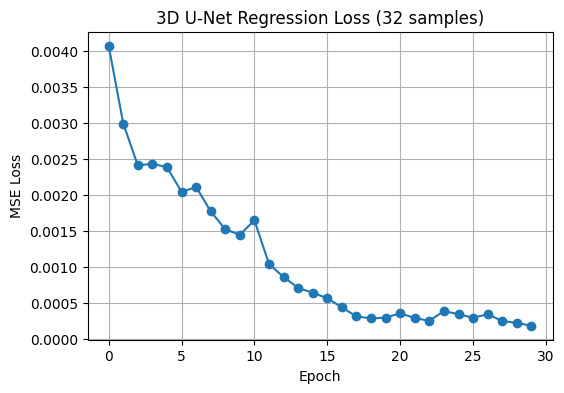

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(train_losses_3d, marker="o")
ax.set_title("3D U-Net Regression Loss (32 samples)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.grid(True)

loss_curve_path = FIG_DIR / "loss_curve_32samples.png"
fig.savefig(loss_curve_path, dpi=150, bbox_inches="tight")
print("Saved:", loss_curve_path)
plt.show()

### 11.Evaluation

In [25]:
@torch.no_grad()
def evaluate_regression_3d(model, loader, device):
    model.eval()
    total_mse = 0.0
    total_mae = 0.0
    n_batches = 0

    for x0, x1 in loader:
        x0 = x0.to(device)
        x1 = x1.to(device)

        pred = model(x0)

        mse = F.mse_loss(pred, x1).item()
        mae = F.l1_loss(pred, x1).item()

        total_mse += mse
        total_mae += mae
        n_batches += 1

    return {
        "mse": total_mse / n_batches,
        "mae": total_mae / n_batches
    }

train_metrics_3d = evaluate_regression_3d(model_3d, train_loader_3d, device)
test_metrics_3d  = evaluate_regression_3d(model_3d, test_loader_3d, device)

print("Train metrics 3D:", train_metrics_3d)
print("Test metrics 3D :", test_metrics_3d)

Train metrics 3D: {'mse': 0.00017765181019058218, 'mae': 0.009621578676160425}
Test metrics 3D : {'mse': 0.00026100335890077986, 'mae': 0.011624134262092412}


### 12.Best-slice visualization helper

In [26]:
def save_best_slice_panel_3d(x0_np, x1_np, pred_np, save_path, axis=0, prefix=""):
    """
    x0_np, x1_np, pred_np: shape (D, H, W)
    axis:
        0 -> axial-like
        1 -> coronal-like
        2 -> sagittal-like
    """
    if axis == 0:
        scores = x1_np.sum(axis=(1, 2))
    elif axis == 1:
        scores = x1_np.sum(axis=(0, 2))
    elif axis == 2:
        scores = x1_np.sum(axis=(0, 1))
    else:
        raise ValueError("axis must be 0, 1, or 2")

    best_idx = int(np.argmax(scores))

    if axis == 0:
        x0_sl = x0_np[best_idx]
        x1_sl = x1_np[best_idx]
        pred_sl = pred_np[best_idx]
    elif axis == 1:
        x0_sl = x0_np[:, best_idx, :]
        x1_sl = x1_np[:, best_idx, :]
        pred_sl = pred_np[:, best_idx, :]
    else:
        x0_sl = x0_np[:, :, best_idx]
        x1_sl = x1_np[:, :, best_idx]
        pred_sl = pred_np[:, :, best_idx]

    err_sl = np.abs(pred_sl - x1_sl)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(x0_sl, cmap="gray")
    axes[0].set_title(f"{prefix}Input CT")
    axes[0].axis("off")

    axes[1].imshow(x1_sl, cmap="hot")
    axes[1].set_title(f"{prefix}Target Dose")
    axes[1].axis("off")

    axes[2].imshow(pred_sl, cmap="hot")
    axes[2].set_title(f"{prefix}Predicted Dose")
    axes[2].axis("off")

    axes[3].imshow(err_sl, cmap="hot")
    axes[3].set_title(f"{prefix}Absolute Error")
    axes[3].axis("off")

    plt.tight_layout()
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print("Saved:", save_path)
    plt.show()

    return best_idx

### 13.Save train best-slice panel

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/regression_3d_32samples/train_best_slice_axis0_32samples.png


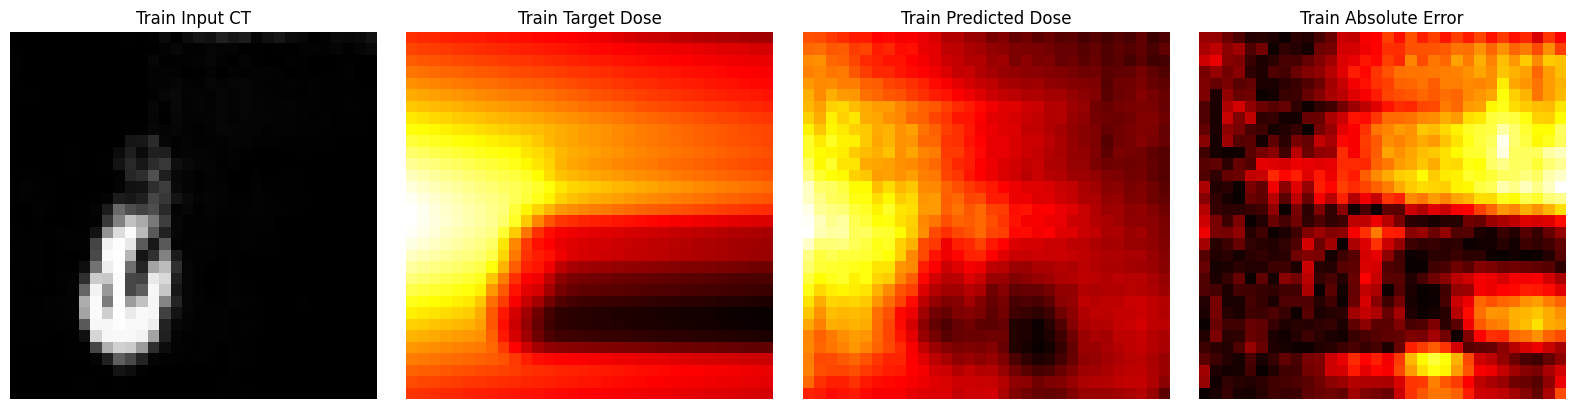

Train best slice index: 5


In [27]:
model_3d.eval()

x0, x1 = next(iter(train_loader_3d))
x0 = x0.to(device)
x1 = x1.to(device)

with torch.no_grad():
    pred = model_3d(x0)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()

train_fig_path = FIG_DIR / "train_best_slice_axis0_32samples.png"
best_idx_train = save_best_slice_panel_3d(
    x0_np, x1_np, pred_np,
    train_fig_path,
    axis=0,
    prefix="Train "
)
print("Train best slice index:", best_idx_train)

### 14.Save test best-slice panel

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/regression_3d_32samples/test_best_slice_axis0_32samples.png


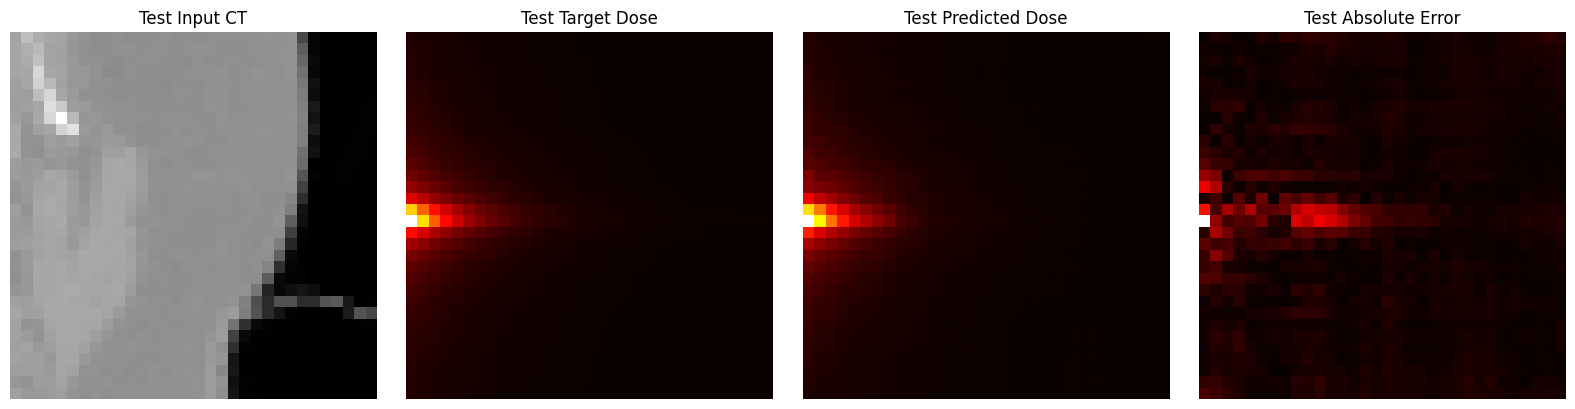

Test best slice index: 16


In [28]:
model_3d.eval()

x0, x1 = next(iter(test_loader_3d))
x0 = x0.to(device)
x1 = x1.to(device)

with torch.no_grad():
    pred = model_3d(x0)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()

test_fig_path = FIG_DIR / "test_best_slice_axis0_32samples.png"
best_idx_test = save_best_slice_panel_3d(
    x0_np, x1_np, pred_np,
    test_fig_path,
    axis=0,
    prefix="Test "
)
print("Test best slice index:", best_idx_test)

### 15.Save checkpoint

In [29]:
ckpt_path = CKPT_DIR / "unet3d_regression_32samples.pt"

torch.save({
    "model_state_dict": model_3d.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses": train_losses_3d,
    "train_metrics": train_metrics_3d,
    "test_metrics": test_metrics_3d,
    "dose_scale": 1000.0,
    "num_epochs": num_epochs,
    "num_train_samples": 32,
    "num_test_samples": 16,
}, ckpt_path)

print("Saved checkpoint to:", ckpt_path)

Saved checkpoint to: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/unet3d_regression_32samples.pt


英文翻译为：

## Under the same 32-train / 16-test setting, increase the 3D U-Net's base_ch from 16 to 24

### 1. Set new output directory and checkpoint name

In [30]:
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose")
SPLIT_DIR = BASE_DIR / "data" / "splits"
CKPT_DIR = BASE_DIR / "outputs" / "checkpoints"
FIG_DIR = BASE_DIR / "outputs" / "figures" / "regression_3d_base24"

CKPT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("SPLIT_DIR:", SPLIT_DIR)
print("CKPT_DIR :", CKPT_DIR)
print("FIG_DIR  :", FIG_DIR)

SPLIT_DIR: /content/drive/MyDrive/rectified_flow_ct2dose/data/splits
CKPT_DIR : /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints
FIG_DIR  : /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/regression_3d_base24


### 2. Load 3D dataset, keeping the same 32/16 setting

In [31]:
from pathlib import Path
from torch.utils.data import DataLoader, Subset

train_manifest_3d = SPLIT_DIR / "train_pairs_3d.json"
test_manifest_3d  = SPLIT_DIR / "test_pairs_3d.json"

train_dataset_3d = CubePair3DDataset(train_manifest_3d, dose_scale=1000.0)
test_dataset_3d  = CubePair3DDataset(test_manifest_3d, dose_scale=1000.0)

train_subset_3d = Subset(train_dataset_3d, list(range(32)))
test_subset_3d  = Subset(test_dataset_3d, list(range(16)))

train_loader_3d = DataLoader(train_subset_3d, batch_size=2, shuffle=True, num_workers=0)
test_loader_3d  = DataLoader(test_subset_3d, batch_size=2, shuffle=False, num_workers=0)

print("Train subset size:", len(train_subset_3d))
print("Test subset size :", len(test_subset_3d))

Train subset size: 32
Test subset size : 16


### 3. Instantiate a stronger 3D U-Net

In [32]:
import torch
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model_3d = UNet3D(in_ch=1, out_ch=1, base_ch=24).to(device)
optimizer = torch.optim.Adam(model_3d.parameters(), lr=1e-3)

def regression_loss_3d(model, x0, x1):
    pred = model(x0)
    loss = F.mse_loss(pred, x1)
    return loss, pred

device: cuda


### 4. Train for 30 epochs

In [34]:
num_epochs = 30
train_losses_3d = []

for epoch in range(num_epochs):
    model_3d.train()
    running_loss = 0.0

    for x0, x1 in train_loader_3d:
        x0 = x0.to(device)
        x1 = x1.to(device)

        optimizer.zero_grad()
        loss, pred = regression_loss_3d(model_3d, x0, x1)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader_3d)
    train_losses_3d.append(epoch_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - train loss: {epoch_loss:.6f}")

Epoch 1/30 - train loss: 0.006889
Epoch 2/30 - train loss: 0.004048
Epoch 3/30 - train loss: 0.003038
Epoch 4/30 - train loss: 0.002485
Epoch 5/30 - train loss: 0.002200
Epoch 6/30 - train loss: 0.002154
Epoch 7/30 - train loss: 0.003119
Epoch 8/30 - train loss: 0.002793
Epoch 9/30 - train loss: 0.002385
Epoch 10/30 - train loss: 0.002106
Epoch 11/30 - train loss: 0.002286
Epoch 12/30 - train loss: 0.001419
Epoch 13/30 - train loss: 0.001366
Epoch 14/30 - train loss: 0.000922
Epoch 15/30 - train loss: 0.000782
Epoch 16/30 - train loss: 0.000648
Epoch 17/30 - train loss: 0.000619
Epoch 18/30 - train loss: 0.000530
Epoch 19/30 - train loss: 0.000358
Epoch 20/30 - train loss: 0.000407
Epoch 21/30 - train loss: 0.000404
Epoch 22/30 - train loss: 0.000310
Epoch 23/30 - train loss: 0.000296
Epoch 24/30 - train loss: 0.000346
Epoch 25/30 - train loss: 0.000368
Epoch 26/30 - train loss: 0.000300
Epoch 27/30 - train loss: 0.000301
Epoch 28/30 - train loss: 0.000281
Epoch 29/30 - train loss: 0.0

### 5. Save loss curve

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/regression_3d_base24/loss_curve_base24.png


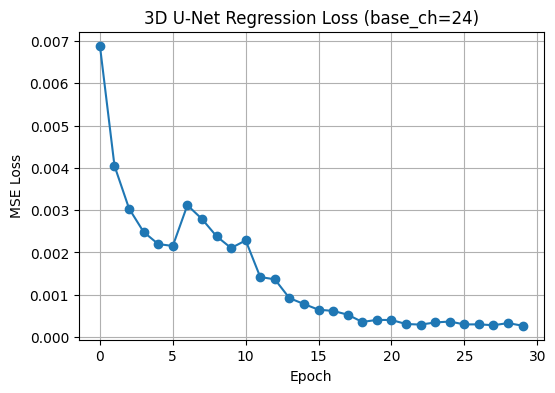

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(train_losses_3d, marker="o")
ax.set_title("3D U-Net Regression Loss (base_ch=24)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.grid(True)

loss_path = FIG_DIR / "loss_curve_base24.png"
fig.savefig(loss_path, dpi=150, bbox_inches="tight")
print("Saved:", loss_path)
plt.show()

### 6. Compute train/test metrics

In [36]:
@torch.no_grad()
def evaluate_regression_3d(model, loader, device):
    model.eval()
    total_mse = 0.0
    total_mae = 0.0
    n_batches = 0

    for x0, x1 in loader:
        x0 = x0.to(device)
        x1 = x1.to(device)

        pred = model(x0)

        mse = F.mse_loss(pred, x1).item()
        mae = F.l1_loss(pred, x1).item()

        total_mse += mse
        total_mae += mae
        n_batches += 1

    return {
        "mse": total_mse / n_batches,
        "mae": total_mae / n_batches
    }

train_metrics_3d = evaluate_regression_3d(model_3d, train_loader_3d, device)
test_metrics_3d  = evaluate_regression_3d(model_3d, test_loader_3d, device)

print("Train metrics 3D:", train_metrics_3d)
print("Test metrics 3D :", test_metrics_3d)

Train metrics 3D: {'mse': 0.00024365166882489575, 'mae': 0.011430244368966669}
Test metrics 3D : {'mse': 0.00032914660550886765, 'mae': 0.01282844808883965}


### 7. Save train best-slice plots

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/regression_3d_base24/train_best_slice_base24.png


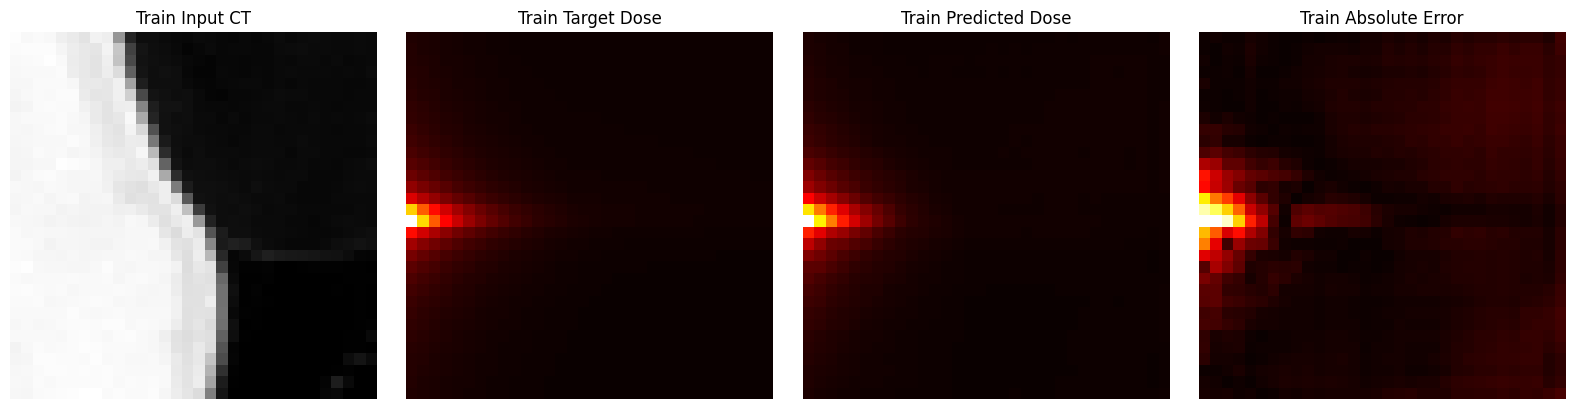

Train best slice index: 16


In [37]:
model_3d.eval()

x0, x1 = next(iter(train_loader_3d))
x0 = x0.to(device)
x1 = x1.to(device)

with torch.no_grad():
    pred = model_3d(x0)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()

train_fig_path = FIG_DIR / "train_best_slice_base24.png"
best_idx_train = save_best_slice_panel_3d(
    x0_np, x1_np, pred_np,
    train_fig_path,
    axis=0,
    prefix="Train "
)

print("Train best slice index:", best_idx_train)

### 8. Save test best-slice plots

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/regression_3d_base24/test_best_slice_base24.png


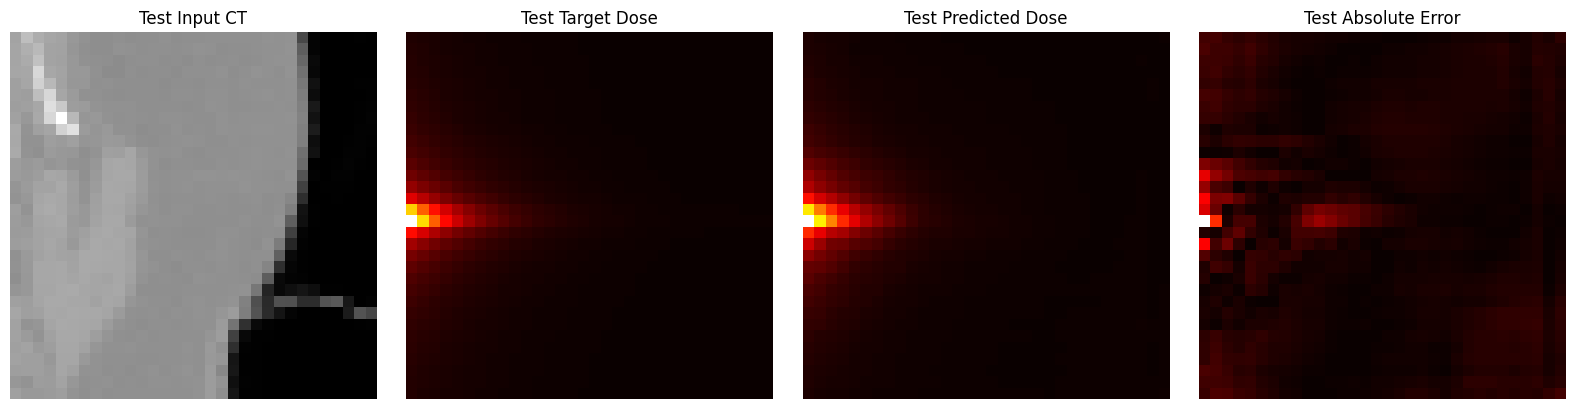

Test best slice index: 16


In [38]:
model_3d.eval()

x0, x1 = next(iter(test_loader_3d))
x0 = x0.to(device)
x1 = x1.to(device)

with torch.no_grad():
    pred = model_3d(x0)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()

test_fig_path = FIG_DIR / "test_best_slice_base24.png"
best_idx_test = save_best_slice_panel_3d(
    x0_np, x1_np, pred_np,
    test_fig_path,
    axis=0,
    prefix="Test "
)

print("Test best slice index:", best_idx_test)

### 9. Save checkpoint

In [39]:
ckpt_path = CKPT_DIR / "unet3d_regression_base24.pt"

torch.save({
    "model_state_dict": model_3d.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses": train_losses_3d,
    "train_metrics": train_metrics_3d,
    "test_metrics": test_metrics_3d,
    "dose_scale": 1000.0,
    "num_epochs": num_epochs,
    "num_train_samples": 32,
    "num_test_samples": 16,
    "base_ch": 24,
}, ckpt_path)

print("Saved checkpoint to:", ckpt_path)

Saved checkpoint to: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/unet3d_regression_base24.pt


### 10. Save a summary text file as well

In [40]:
summary_path = FIG_DIR / "summary_base24.txt"

summary_text = f"""
3D U-Net regression baseline (base_ch=24)

Train subset: 32
Test subset : 16
Epochs      : 30
Dose scale  : 1000.0

Train metrics:
MSE = {train_metrics_3d['mse']:.6f}
MAE = {train_metrics_3d['mae']:.6f}

Test metrics:
MSE = {test_metrics_3d['mse']:.6f}
MAE = {test_metrics_3d['mae']:.6f}
"""

with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print("Saved:", summary_path)
print(summary_text)

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/regression_3d_base24/summary_base24.txt

3D U-Net regression baseline (base_ch=24)

Train subset: 32
Test subset : 16
Epochs      : 30
Dose scale  : 1000.0

Train metrics:
MSE = 0.000244
MAE = 0.011430

Test metrics:
MSE = 0.000329
MAE = 0.012828



## 64-sample 3D regression baseline with base_ch=24

### 1.Imports

In [41]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset


### 2.Set Seed

In [42]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

### 3.Set all paths

In [43]:
BASE_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose")
SPLIT_DIR = BASE_DIR / "data" / "splits"
CKPT_DIR = BASE_DIR / "outputs" / "checkpoints"
FIG_DIR = BASE_DIR / "outputs" / "figures" / "regression_3d_64samples_base24"

CKPT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

train_manifest_3d = SPLIT_DIR / "train_pairs_3d.json"
test_manifest_3d  = SPLIT_DIR / "test_pairs_3d.json"

print("train manifest:", train_manifest_3d)
print("test manifest :", test_manifest_3d)
print("CKPT_DIR      :", CKPT_DIR)
print("FIG_DIR       :", FIG_DIR)

train manifest: /content/drive/MyDrive/rectified_flow_ct2dose/data/splits/train_pairs_3d.json
test manifest : /content/drive/MyDrive/rectified_flow_ct2dose/data/splits/test_pairs_3d.json
CKPT_DIR      : /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints
FIG_DIR       : /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/regression_3d_64samples_base24


### 4.Dataset

In [44]:
def normalize_ct(x):
    x = np.clip(x, -1024.0, 1500.0)
    x = (x + 1024.0) / (1500.0 + 1024.0)
    return x.astype(np.float32)

class CubePair3DDataset(Dataset):
    def __init__(self, manifest_path, dose_scale=1000.0):
        with open(manifest_path, "r", encoding="utf-8") as f:
            self.records = json.load(f)
        self.dose_scale = dose_scale

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        x0 = np.load(rec["input_path"]).astype(np.float32)   # (32,32,32)
        x1 = np.load(rec["output_path"]).astype(np.float32)  # (32,32,32)

        x0 = normalize_ct(x0)
        x1 = (x1 * self.dose_scale).astype(np.float32)

        x0 = torch.from_numpy(x0).unsqueeze(0)   # (1,D,H,W)
        x1 = torch.from_numpy(x1).unsqueeze(0)   # (1,D,H,W)

        return x0, x1

### 5.Dataloaders

In [45]:
train_dataset_3d = CubePair3DDataset(train_manifest_3d, dose_scale=1000.0)
test_dataset_3d  = CubePair3DDataset(test_manifest_3d, dose_scale=1000.0)

train_subset_3d = Subset(train_dataset_3d, list(range(64)))
test_subset_3d  = Subset(test_dataset_3d, list(range(32)))

train_loader_3d = DataLoader(train_subset_3d, batch_size=2, shuffle=True, num_workers=0)
test_loader_3d  = DataLoader(test_subset_3d, batch_size=2, shuffle=False, num_workers=0)

x0, x1 = train_subset_3d[0]
print("single x0:", x0.shape, x0.dtype, x0.min().item(), x0.max().item())
print("single x1:", x1.shape, x1.dtype, x1.min().item(), x1.max().item())

bx0, bx1 = next(iter(train_loader_3d))
print("batch x0:", bx0.shape)
print("batch x1:", bx1.shape)

single x0: torch.Size([1, 32, 32, 32]) torch.float32 0.0033760373480618 0.8727859258651733
single x1: torch.Size([1, 32, 32, 32]) torch.float32 0.0007880193879827857 2.7264456748962402
batch x0: torch.Size([2, 1, 32, 32, 32])
batch x1: torch.Size([2, 1, 32, 32, 32])


### 6.Model

In [46]:
train_dataset_3d = CubePair3DDataset(train_manifest_3d, dose_scale=1000.0)
test_dataset_3d  = CubePair3DDataset(test_manifest_3d, dose_scale=1000.0)

train_subset_3d = Subset(train_dataset_3d, list(range(64)))
test_subset_3d  = Subset(test_dataset_3d, list(range(32)))

train_loader_3d = DataLoader(train_subset_3d, batch_size=2, shuffle=True, num_workers=0)
test_loader_3d  = DataLoader(test_subset_3d, batch_size=2, shuffle=False, num_workers=0)

x0, x1 = train_subset_3d[0]
print("single x0:", x0.shape, x0.dtype, x0.min().item(), x0.max().item())
print("single x1:", x1.shape, x1.dtype, x1.min().item(), x1.max().item())

bx0, bx1 = next(iter(train_loader_3d))
print("batch x0:", bx0.shape)
print("batch x1:", bx1.shape)

single x0: torch.Size([1, 32, 32, 32]) torch.float32 0.0033760373480618 0.8727859258651733
single x1: torch.Size([1, 32, 32, 32]) torch.float32 0.0007880193879827857 2.7264456748962402
batch x0: torch.Size([2, 1, 32, 32, 32])
batch x1: torch.Size([2, 1, 32, 32, 32])


### 7. Training setup

In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model_3d = UNet3D(in_ch=1, out_ch=1, base_ch=24).to(device)
optimizer = torch.optim.Adam(model_3d.parameters(), lr=1e-3)

def regression_loss_3d(model, x0, x1):
    pred = model(x0)
    loss = F.mse_loss(pred, x1)
    return loss, pred

device: cuda


### 8. Train

In [48]:
num_epochs = 30
train_losses_3d = []

for epoch in range(num_epochs):
    model_3d.train()
    running_loss = 0.0

    for x0, x1 in train_loader_3d:
        x0 = x0.to(device)
        x1 = x1.to(device)

        optimizer.zero_grad()
        loss, pred = regression_loss_3d(model_3d, x0, x1)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader_3d)
    train_losses_3d.append(epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - train loss: {epoch_loss:.6f}")

Epoch 1/30 - train loss: 0.010217
Epoch 2/30 - train loss: 0.003717
Epoch 3/30 - train loss: 0.002574
Epoch 4/30 - train loss: 0.002164
Epoch 5/30 - train loss: 0.001299
Epoch 6/30 - train loss: 0.001062
Epoch 7/30 - train loss: 0.000912
Epoch 8/30 - train loss: 0.000856
Epoch 9/30 - train loss: 0.000766
Epoch 10/30 - train loss: 0.000719
Epoch 11/30 - train loss: 0.000662
Epoch 12/30 - train loss: 0.000793
Epoch 13/30 - train loss: 0.000456
Epoch 14/30 - train loss: 0.000376
Epoch 15/30 - train loss: 0.000428
Epoch 16/30 - train loss: 0.000376
Epoch 17/30 - train loss: 0.000356
Epoch 18/30 - train loss: 0.000324
Epoch 19/30 - train loss: 0.000356
Epoch 20/30 - train loss: 0.000364
Epoch 21/30 - train loss: 0.000263
Epoch 22/30 - train loss: 0.000266
Epoch 23/30 - train loss: 0.000236
Epoch 24/30 - train loss: 0.000277
Epoch 25/30 - train loss: 0.000232
Epoch 26/30 - train loss: 0.000205
Epoch 27/30 - train loss: 0.000199
Epoch 28/30 - train loss: 0.000239
Epoch 29/30 - train loss: 0.0

### 9. Save loss curve

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/regression_3d_64samples_base24/loss_curve_64samples_base24.png


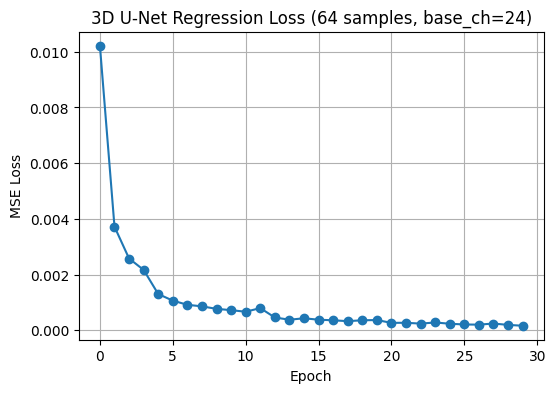

In [49]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(train_losses_3d, marker="o")
ax.set_title("3D U-Net Regression Loss (64 samples, base_ch=24)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.grid(True)

loss_path = FIG_DIR / "loss_curve_64samples_base24.png"
fig.savefig(loss_path, dpi=150, bbox_inches="tight")
print("Saved:", loss_path)
plt.show()

### 10.Evaluation

In [50]:
@torch.no_grad()
def evaluate_regression_3d(model, loader, device):
    model.eval()
    total_mse = 0.0
    total_mae = 0.0
    n_batches = 0

    for x0, x1 in loader:
        x0 = x0.to(device)
        x1 = x1.to(device)

        pred = model(x0)

        mse = F.mse_loss(pred, x1).item()
        mae = F.l1_loss(pred, x1).item()

        total_mse += mse
        total_mae += mae
        n_batches += 1

    return {
        "mse": total_mse / n_batches,
        "mae": total_mae / n_batches
    }

train_metrics_3d = evaluate_regression_3d(model_3d, train_loader_3d, device)
test_metrics_3d  = evaluate_regression_3d(model_3d, test_loader_3d, device)

print("Train metrics 3D:", train_metrics_3d)
print("Test metrics 3D :", test_metrics_3d)

Train metrics 3D: {'mse': 0.000249747390171251, 'mae': 0.010087988281156868}
Test metrics 3D : {'mse': 0.00031895826850814046, 'mae': 0.010947901289910078}


### 11. Best-slice helper

In [51]:
def save_best_slice_panel_3d(x0_np, x1_np, pred_np, save_path, axis=0, prefix=""):
    if axis == 0:
        scores = x1_np.sum(axis=(1, 2))
    elif axis == 1:
        scores = x1_np.sum(axis=(0, 2))
    elif axis == 2:
        scores = x1_np.sum(axis=(0, 1))
    else:
        raise ValueError("axis must be 0, 1, or 2")

    best_idx = int(np.argmax(scores))

    if axis == 0:
        x0_sl = x0_np[best_idx]
        x1_sl = x1_np[best_idx]
        pred_sl = pred_np[best_idx]
    elif axis == 1:
        x0_sl = x0_np[:, best_idx, :]
        x1_sl = x1_np[:, best_idx, :]
        pred_sl = pred_np[:, best_idx, :]
    else:
        x0_sl = x0_np[:, :, best_idx]
        x1_sl = x1_np[:, :, best_idx]
        pred_sl = pred_np[:, :, best_idx]

    err_sl = np.abs(pred_sl - x1_sl)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(x0_sl, cmap="gray")
    axes[0].set_title(f"{prefix}Input CT")
    axes[0].axis("off")

    axes[1].imshow(x1_sl, cmap="hot")
    axes[1].set_title(f"{prefix}Target Dose")
    axes[1].axis("off")

    axes[2].imshow(pred_sl, cmap="hot")
    axes[2].set_title(f"{prefix}Predicted Dose")
    axes[2].axis("off")

    axes[3].imshow(err_sl, cmap="hot")
    axes[3].set_title(f"{prefix}Absolute Error")
    axes[3].axis("off")

    plt.tight_layout()
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print("Saved:", save_path)
    plt.show()

    return best_idx

### 12.Save train best-slice figure

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/regression_3d_64samples_base24/train_best_slice_64samples_base24.png


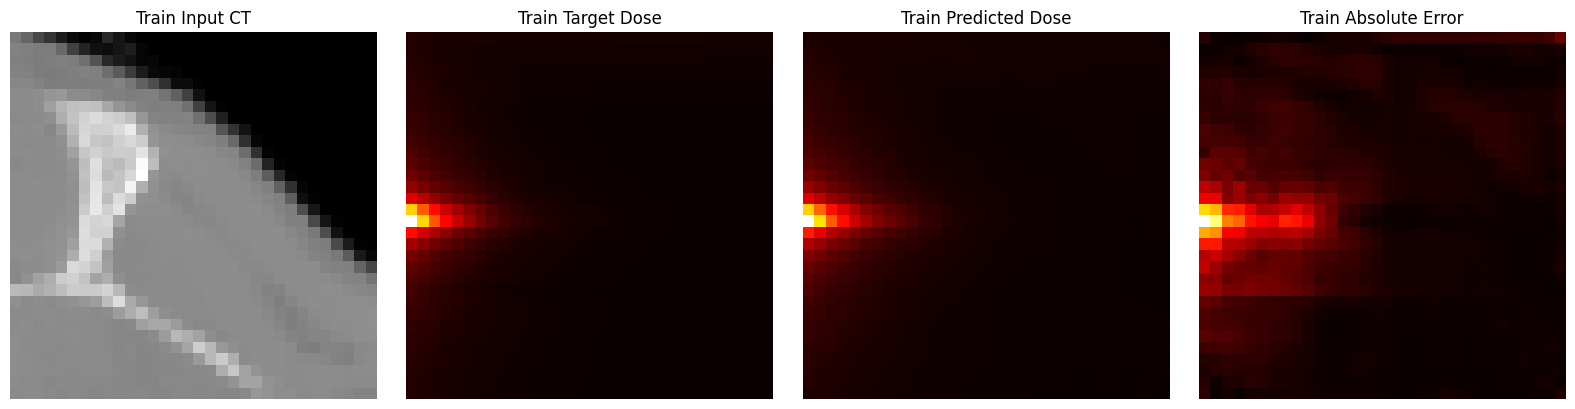

Train best slice index: 16


In [52]:
model_3d.eval()

x0, x1 = next(iter(train_loader_3d))
x0 = x0.to(device)
x1 = x1.to(device)

with torch.no_grad():
    pred = model_3d(x0)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()

train_fig_path = FIG_DIR / "train_best_slice_64samples_base24.png"
best_idx_train = save_best_slice_panel_3d(
    x0_np, x1_np, pred_np,
    train_fig_path,
    axis=0,
    prefix="Train "
)
print("Train best slice index:", best_idx_train)

### 13.Save test best-slice figure

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/regression_3d_64samples_base24/test_best_slice_64samples_base24.png


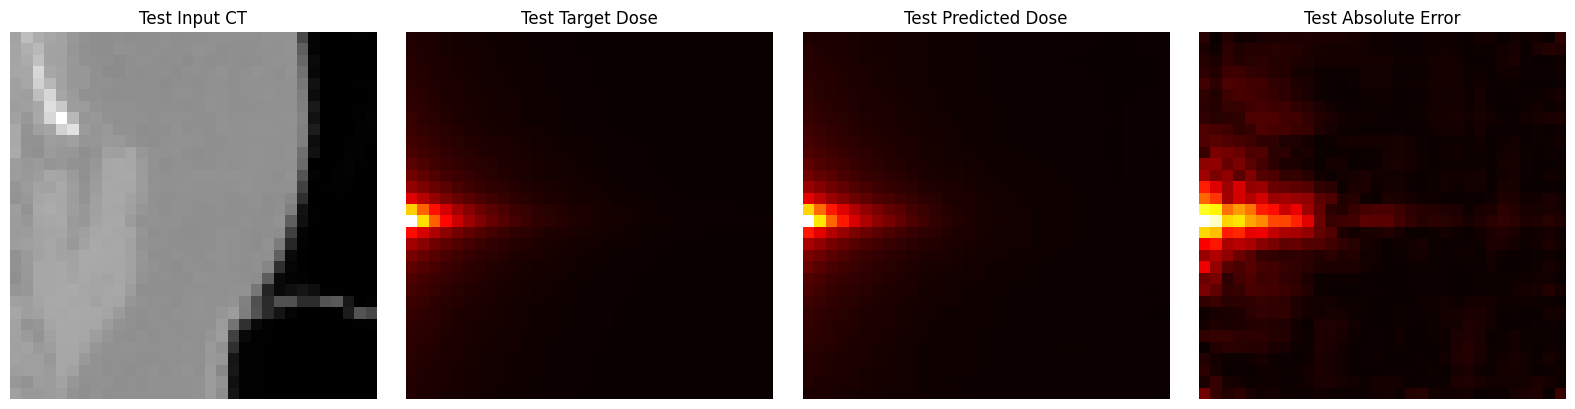

Test best slice index: 16


In [53]:
model_3d.eval()

x0, x1 = next(iter(test_loader_3d))
x0 = x0.to(device)
x1 = x1.to(device)

with torch.no_grad():
    pred = model_3d(x0)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()

test_fig_path = FIG_DIR / "test_best_slice_64samples_base24.png"
best_idx_test = save_best_slice_panel_3d(
    x0_np, x1_np, pred_np,
    test_fig_path,
    axis=0,
    prefix="Test "
)
print("Test best slice index:", best_idx_test)

### 14.Save checkpoint

In [54]:
ckpt_path = CKPT_DIR / "unet3d_regression_64samples_base24.pt"

torch.save({
    "model_state_dict": model_3d.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses": train_losses_3d,
    "train_metrics": train_metrics_3d,
    "test_metrics": test_metrics_3d,
    "dose_scale": 1000.0,
    "num_epochs": num_epochs,
    "num_train_samples": 64,
    "num_test_samples": 32,
    "base_ch": 24,
}, ckpt_path)

print("Saved checkpoint to:", ckpt_path)

Saved checkpoint to: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/unet3d_regression_64samples_base24.pt


### 15.Save short summary text

In [55]:
summary_path = FIG_DIR / "summary_64samples_base24.txt"

summary_text = f"""
3D U-Net regression baseline (64 samples, base_ch=24)

Train subset: 64
Test subset : 32
Epochs      : 30
Dose scale  : 1000.0

Train metrics:
MSE = {train_metrics_3d['mse']:.6f}
MAE = {train_metrics_3d['mae']:.6f}

Test metrics:
MSE = {test_metrics_3d['mse']:.6f}
MAE = {test_metrics_3d['mae']:.6f}
"""

with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print("Saved:", summary_path)
print(summary_text)

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/regression_3d_64samples_base24/summary_64samples_base24.txt

3D U-Net regression baseline (64 samples, base_ch=24)

Train subset: 64
Test subset : 32
Epochs      : 30
Dose scale  : 1000.0

Train metrics:
MSE = 0.000250
MAE = 0.010088

Test metrics:
MSE = 0.000319
MAE = 0.010948



## First 3D conditional flow baseline
(Comparable setup to the 64-sample 3D regression baseline)

### 1.Imports

In [2]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

### 2. Set Seed

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

### 3. Paths

In [4]:
BASE_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose")
SPLIT_DIR = BASE_DIR / "data" / "splits"
CKPT_DIR = BASE_DIR / "outputs" / "checkpoints"
FIG_DIR = BASE_DIR / "outputs" / "figures" / "flow_3d_64samples_base24"

CKPT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

train_manifest_3d = SPLIT_DIR / "train_pairs_3d.json"
test_manifest_3d  = SPLIT_DIR / "test_pairs_3d.json"

print("train manifest:", train_manifest_3d)
print("test manifest :", test_manifest_3d)
print("CKPT_DIR      :", CKPT_DIR)
print("FIG_DIR       :", FIG_DIR)

train manifest: /content/drive/MyDrive/rectified_flow_ct2dose/data/splits/train_pairs_3d.json
test manifest : /content/drive/MyDrive/rectified_flow_ct2dose/data/splits/test_pairs_3d.json
CKPT_DIR      : /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints
FIG_DIR       : /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_3d_64samples_base24


### 4. Dataset

In [5]:
def normalize_ct(x):
    x = np.clip(x, -1024.0, 1500.0)
    x = (x + 1024.0) / (1500.0 + 1024.0)
    return x.astype(np.float32)

class CubePair3DDataset(Dataset):
    def __init__(self, manifest_path, dose_scale=1000.0):
        with open(manifest_path, "r", encoding="utf-8") as f:
            self.records = json.load(f)
        self.dose_scale = dose_scale

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        x0 = np.load(rec["input_path"]).astype(np.float32)   # (32,32,32)
        x1 = np.load(rec["output_path"]).astype(np.float32)  # (32,32,32)

        x0 = normalize_ct(x0)
        x1 = (x1 * self.dose_scale).astype(np.float32)

        x0 = torch.from_numpy(x0).unsqueeze(0)   # (1,D,H,W)
        x1 = torch.from_numpy(x1).unsqueeze(0)   # (1,D,H,W)

        return x0, x1


### 5. Dataloaders

In [6]:
train_dataset_3d = CubePair3DDataset(train_manifest_3d, dose_scale=1000.0)
test_dataset_3d  = CubePair3DDataset(test_manifest_3d, dose_scale=1000.0)

train_subset_3d = Subset(train_dataset_3d, list(range(64)))
test_subset_3d  = Subset(test_dataset_3d, list(range(32)))

train_loader_3d = DataLoader(train_subset_3d, batch_size=2, shuffle=True, num_workers=0)
test_loader_3d  = DataLoader(test_subset_3d, batch_size=2, shuffle=False, num_workers=0)

x0, x1 = train_subset_3d[0]
print("single x0:", x0.shape, x0.dtype, x0.min().item(), x0.max().item())
print("single x1:", x1.shape, x1.dtype, x1.min().item(), x1.max().item())

bx0, bx1 = next(iter(train_loader_3d))
print("batch x0:", bx0.shape)
print("batch x1:", bx1.shape)


single x0: torch.Size([1, 32, 32, 32]) torch.float32 0.0033760373480618 0.8727859258651733
single x1: torch.Size([1, 32, 32, 32]) torch.float32 0.0007880193879827857 2.7264456748962402
batch x0: torch.Size([2, 1, 32, 32, 32])
batch x1: torch.Size([2, 1, 32, 32, 32])


### 6. Model Blocks

In [7]:
class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ConditionalUNetFlow3D(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base_ch=24):
        super().__init__()

        self.enc1 = DoubleConv3D(in_ch, base_ch)
        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv3D(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv3D(base_ch * 2, base_ch * 4)

        self.up2 = nn.ConvTranspose3d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose3d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(base_ch * 2, base_ch)

        self.out_conv = nn.Conv3d(base_ch, out_ch, kernel_size=1)

    def forward(self, xt, x0, t):
        # xt, x0: (B,1,D,H,W)
        # t:      (B,1,1,1,1)
        t_map = t.expand(-1, 1, xt.shape[2], xt.shape[3], xt.shape[4])  # (B,1,D,H,W)
        inp = torch.cat([xt, x0, t_map], dim=1)  # (B,3,D,H,W)

        e1 = self.enc1(inp)
        e2 = self.enc2(self.pool1(e1))
        b  = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)  # predicted velocity

### 7. Device, optimizer, flow loss

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model_3d = ConditionalUNetFlow3D(in_ch=3, out_ch=1, base_ch=24).to(device)
optimizer = torch.optim.Adam(model_3d.parameters(), lr=1e-3)

def flow_matching_loss_3d(model, x0, x1):
    """
    x0, x1: (B,1,D,H,W)
    """
    B = x0.shape[0]
    t = torch.rand(B, 1, 1, 1, 1, device=x0.device)

    xt = (1.0 - t) * x0 + t * x1
    target_velocity = x1 - x0

    pred_velocity = model(xt, x0, t)
    loss = F.mse_loss(pred_velocity, target_velocity)
    return loss

device: cuda


### 8. Training

In [9]:
num_epochs = 30
train_losses_3d = []

for epoch in range(num_epochs):
    model_3d.train()
    running_loss = 0.0

    for x0, x1 in train_loader_3d:
        x0 = x0.to(device)
        x1 = x1.to(device)

        optimizer.zero_grad()
        loss = flow_matching_loss_3d(model_3d, x0, x1)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader_3d)
    train_losses_3d.append(epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - train loss: {epoch_loss:.6f}")


Epoch 1/30 - train loss: 0.128735
Epoch 2/30 - train loss: 0.026623
Epoch 3/30 - train loss: 0.016077
Epoch 4/30 - train loss: 0.010368
Epoch 5/30 - train loss: 0.007914
Epoch 6/30 - train loss: 0.006349
Epoch 7/30 - train loss: 0.004855
Epoch 8/30 - train loss: 0.003968
Epoch 9/30 - train loss: 0.005042
Epoch 10/30 - train loss: 0.003494
Epoch 11/30 - train loss: 0.002340
Epoch 12/30 - train loss: 0.002203
Epoch 13/30 - train loss: 0.001812
Epoch 14/30 - train loss: 0.001734
Epoch 15/30 - train loss: 0.001559
Epoch 16/30 - train loss: 0.001642
Epoch 17/30 - train loss: 0.001195
Epoch 18/30 - train loss: 0.001219
Epoch 19/30 - train loss: 0.001448
Epoch 20/30 - train loss: 0.001372
Epoch 21/30 - train loss: 0.001016
Epoch 22/30 - train loss: 0.000817
Epoch 23/30 - train loss: 0.000816
Epoch 24/30 - train loss: 0.000907
Epoch 25/30 - train loss: 0.000685
Epoch 26/30 - train loss: 0.000634
Epoch 27/30 - train loss: 0.000827
Epoch 28/30 - train loss: 0.000731
Epoch 29/30 - train loss: 0.0

### 9. Save loss curve

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_3d_64samples_base24/loss_curve_64samples_base24.png


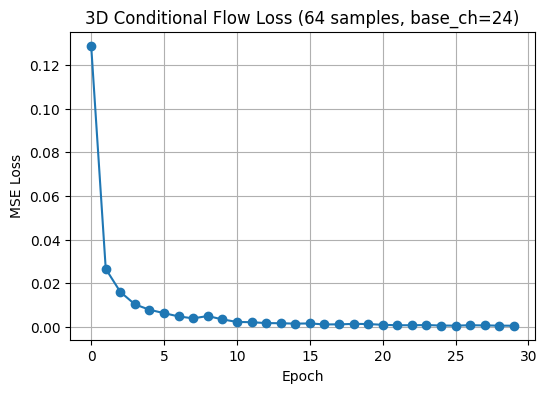

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(train_losses_3d, marker="o")
ax.set_title("3D Conditional Flow Loss (64 samples, base_ch=24)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.grid(True)

loss_path = FIG_DIR / "loss_curve_64samples_base24.png"
fig.savefig(loss_path, dpi=150, bbox_inches="tight")
print("Saved:", loss_path)
plt.show()

### 10. Euler Sampler

In [12]:
@torch.no_grad()
def euler_sample_flow_3d(model, x0, n_steps=30):
    """
    x0: (B,1,D,H,W)
    """
    model.eval()
    z = x0.clone()
    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((z.shape[0], 1, 1, 1, 1), k / n_steps, device=z.device)
        v = model(z, x0, t)
        z = z + dt * v

    return z

### 11. Evaluation

In [13]:
@torch.no_grad()
def evaluate_flow_3d(model, loader, device, n_steps=30):
    model.eval()
    total_mse = 0.0
    total_mae = 0.0
    n_batches = 0

    for x0, x1 in loader:
        x0 = x0.to(device)
        x1 = x1.to(device)

        pred = euler_sample_flow_3d(model, x0, n_steps=n_steps)

        mse = F.mse_loss(pred, x1).item()
        mae = F.l1_loss(pred, x1).item()

        total_mse += mse
        total_mae += mae
        n_batches += 1

    return {
        "mse": total_mse / n_batches,
        "mae": total_mae / n_batches
    }

train_metrics_3d = evaluate_flow_3d(model_3d, train_loader_3d, device, n_steps=30)
test_metrics_3d  = evaluate_flow_3d(model_3d, test_loader_3d, device, n_steps=30)

print("Train metrics 3D:", train_metrics_3d)
print("Test metrics 3D :", test_metrics_3d)

Train metrics 3D: {'mse': 0.000545497900020564, 'mae': 0.01659242680761963}
Test metrics 3D : {'mse': 0.000759508990086033, 'mae': 0.01865438313689083}


### 12. Best-slice helper

In [14]:
def save_best_slice_panel_3d(x0_np, x1_np, pred_np, save_path, axis=0, prefix=""):
    if axis == 0:
        scores = x1_np.sum(axis=(1, 2))
    elif axis == 1:
        scores = x1_np.sum(axis=(0, 2))
    elif axis == 2:
        scores = x1_np.sum(axis=(0, 1))
    else:
        raise ValueError("axis must be 0, 1, or 2")

    best_idx = int(np.argmax(scores))

    if axis == 0:
        x0_sl = x0_np[best_idx]
        x1_sl = x1_np[best_idx]
        pred_sl = pred_np[best_idx]
    elif axis == 1:
        x0_sl = x0_np[:, best_idx, :]
        x1_sl = x1_np[:, best_idx, :]
        pred_sl = pred_np[:, best_idx, :]
    else:
        x0_sl = x0_np[:, :, best_idx]
        x1_sl = x1_np[:, :, best_idx]
        pred_sl = pred_np[:, :, best_idx]

    err_sl = np.abs(pred_sl - x1_sl)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(x0_sl, cmap="gray")
    axes[0].set_title(f"{prefix}Input CT")
    axes[0].axis("off")

    axes[1].imshow(x1_sl, cmap="hot")
    axes[1].set_title(f"{prefix}Target Dose")
    axes[1].axis("off")

    axes[2].imshow(pred_sl, cmap="hot")
    axes[2].set_title(f"{prefix}Predicted Dose")
    axes[2].axis("off")

    axes[3].imshow(err_sl, cmap="hot")
    axes[3].set_title(f"{prefix}Absolute Error")
    axes[3].axis("off")

    plt.tight_layout()
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print("Saved:", save_path)
    plt.show()

    return best_idx

### 13. Save train best-slice figure

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_3d_64samples_base24/train_best_slice_64samples_base24.png


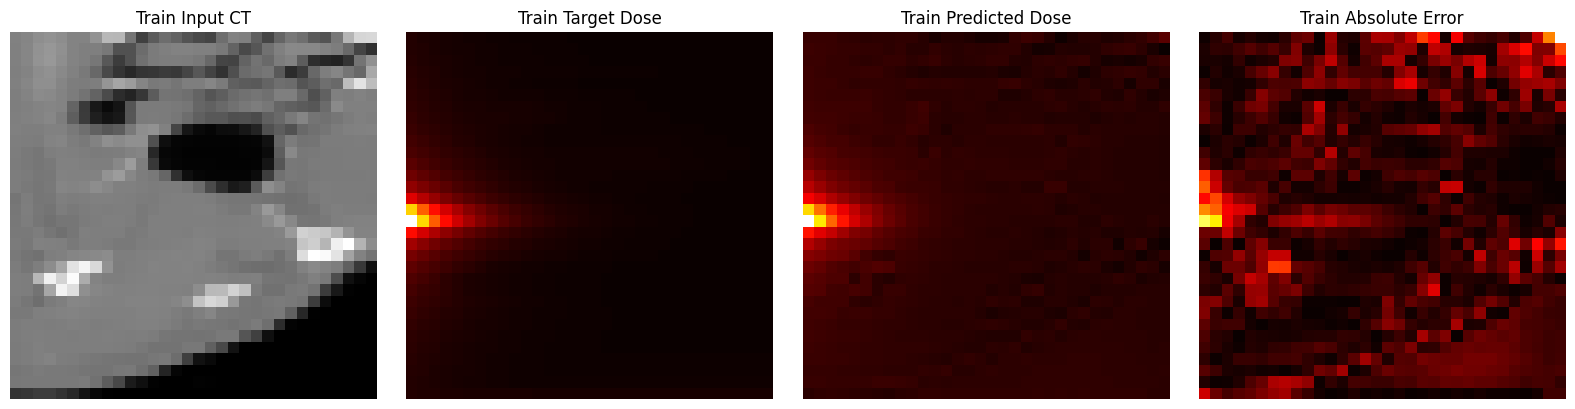

Train best slice index: 16


In [15]:
model_3d.eval()

x0, x1 = next(iter(train_loader_3d))
x0 = x0.to(device)
x1 = x1.to(device)

with torch.no_grad():
    pred = euler_sample_flow_3d(model_3d, x0, n_steps=30)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()

train_fig_path = FIG_DIR / "train_best_slice_64samples_base24.png"
best_idx_train = save_best_slice_panel_3d(
    x0_np, x1_np, pred_np,
    train_fig_path,
    axis=0,
    prefix="Train "
)
print("Train best slice index:", best_idx_train)

### 14. Save test best-slice figure

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_3d_64samples_base24/test_best_slice_64samples_base24.png


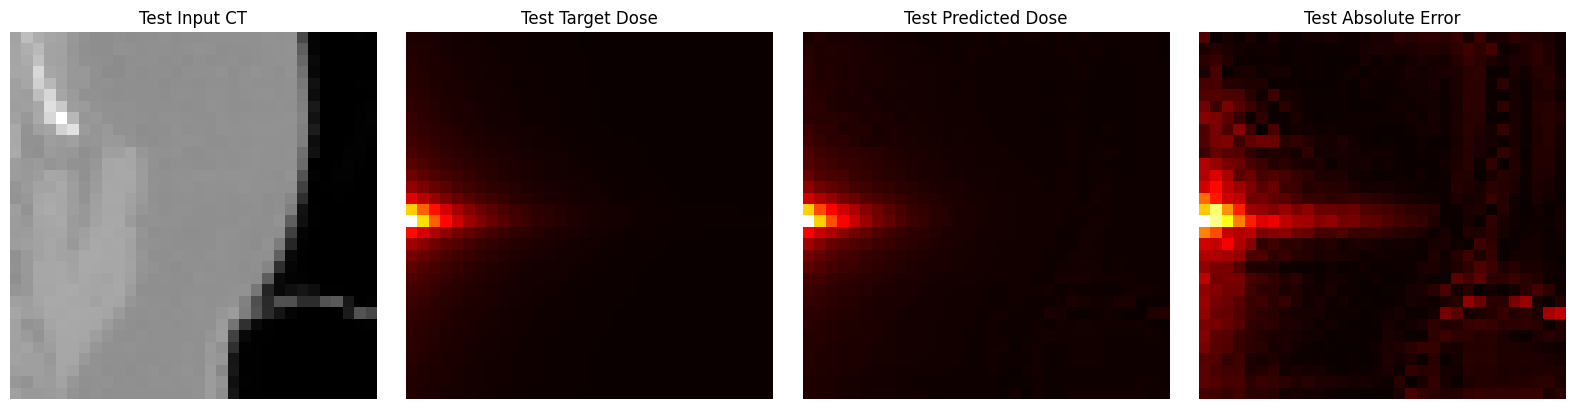

Test best slice index: 16


In [16]:
model_3d.eval()

x0, x1 = next(iter(test_loader_3d))
x0 = x0.to(device)
x1 = x1.to(device)

with torch.no_grad():
    pred = euler_sample_flow_3d(model_3d, x0, n_steps=30)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()

test_fig_path = FIG_DIR / "test_best_slice_64samples_base24.png"
best_idx_test = save_best_slice_panel_3d(
    x0_np, x1_np, pred_np,
    test_fig_path,
    axis=0,
    prefix="Test "
)
print("Test best slice index:", best_idx_test)

### 15. Save checkpoint

In [17]:
ckpt_path = CKPT_DIR / "conditional_unet3d_flow_64samples_base24.pt"

torch.save({
    "model_state_dict": model_3d.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses": train_losses_3d,
    "train_metrics": train_metrics_3d,
    "test_metrics": test_metrics_3d,
    "dose_scale": 1000.0,
    "num_epochs": num_epochs,
    "num_train_samples": 64,
    "num_test_samples": 32,
    "base_ch": 24,
    "n_steps": 30,
}, ckpt_path)

print("Saved checkpoint to:", ckpt_path)

Saved checkpoint to: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/conditional_unet3d_flow_64samples_base24.pt


### 16. Save short summary

In [18]:
summary_path = FIG_DIR / "summary_64samples_base24.txt"

summary_text = f"""
3D conditional flow baseline (64 samples, base_ch=24)

Train subset: 64
Test subset : 32
Epochs      : 30
Dose scale  : 1000.0
Euler steps : 30

Train metrics:
MSE = {train_metrics_3d['mse']:.6f}
MAE = {train_metrics_3d['mae']:.6f}

Test metrics:
MSE = {test_metrics_3d['mse']:.6f}
MAE = {test_metrics_3d['mae']:.6f}
"""

with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print("Saved:", summary_path)
print(summary_text)

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_3d_64samples_base24/summary_64samples_base24.txt

3D conditional flow baseline (64 samples, base_ch=24)

Train subset: 64
Test subset : 32
Epochs      : 30
Dose scale  : 1000.0
Euler steps : 30

Train metrics:
MSE = 0.000545
MAE = 0.016592

Test metrics:
MSE = 0.000760
MAE = 0.018654



## Re-evaluate existing 3D conditional flow checkpoint
 (with higher Euler steps: 30 / 50 / 100 ;no retraining)

### 1. Paths

In [19]:
BASE_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose")
SPLIT_DIR = BASE_DIR / "data" / "splits"
CKPT_DIR = BASE_DIR / "outputs" / "checkpoints"
FIG_DIR = BASE_DIR / "outputs" / "figures" / "flow_3d_64samples_base24_resampling"

FIG_DIR.mkdir(parents=True, exist_ok=True)
CKPT_PATH = CKPT_DIR / "conditional_unet3d_flow_64samples_base24.pt"

train_manifest_3d = SPLIT_DIR / "train_pairs_3d.json"
test_manifest_3d  = SPLIT_DIR / "test_pairs_3d.json"

print("Checkpoint:", CKPT_PATH)
print("Exists:", CKPT_PATH.exists())
print("FIG_DIR:", FIG_DIR)

Checkpoint: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/conditional_unet3d_flow_64samples_base24.pt
Exists: True
FIG_DIR: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_3d_64samples_base24_resampling


### 2. Dataset

In [20]:
def normalize_ct(x):
    x = np.clip(x, -1024.0, 1500.0)
    x = (x + 1024.0) / (1500.0 + 1024.0)
    return x.astype(np.float32)

class CubePair3DDataset(Dataset):
    def __init__(self, manifest_path, dose_scale=1000.0):
        with open(manifest_path, "r", encoding="utf-8") as f:
            self.records = json.load(f)
        self.dose_scale = dose_scale

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        x0 = np.load(rec["input_path"]).astype(np.float32)
        x1 = np.load(rec["output_path"]).astype(np.float32)

        x0 = normalize_ct(x0)
        x1 = (x1 * self.dose_scale).astype(np.float32)

        x0 = torch.from_numpy(x0).unsqueeze(0)   # (1,D,H,W)
        x1 = torch.from_numpy(x1).unsqueeze(0)   # (1,D,H,W)

        return x0, x1

### 3. Dataloaders

In [21]:
train_dataset_3d = CubePair3DDataset(train_manifest_3d, dose_scale=1000.0)
test_dataset_3d  = CubePair3DDataset(test_manifest_3d, dose_scale=1000.0)

train_subset_3d = Subset(train_dataset_3d, list(range(64)))
test_subset_3d  = Subset(test_dataset_3d, list(range(32)))


train_loader_3d = DataLoader(train_subset_3d, batch_size=2, shuffle=False, num_workers=0)
test_loader_3d  = DataLoader(test_subset_3d, batch_size=2, shuffle=False, num_workers=0)

print("Train subset:", len(train_subset_3d))
print("Test subset :", len(test_subset_3d))


Train subset: 64
Test subset : 32


### 4. Model

In [22]:
class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class ConditionalUNetFlow3D(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base_ch=24):
        super().__init__()

        self.enc1 = DoubleConv3D(in_ch, base_ch)
        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv3D(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv3D(base_ch * 2, base_ch * 4)

        self.up2 = nn.ConvTranspose3d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose3d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(base_ch * 2, base_ch)

        self.out_conv = nn.Conv3d(base_ch, out_ch, kernel_size=1)

    def forward(self, xt, x0, t):
        t_map = t.expand(-1, 1, xt.shape[2], xt.shape[3], xt.shape[4])
        inp = torch.cat([xt, x0, t_map], dim=1)

        e1 = self.enc1(inp)
        e2 = self.enc2(self.pool1(e1))
        b  = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)

### 5. Load checkpoint

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

ckpt = torch.load(CKPT_PATH, map_location=device)

model_3d = ConditionalUNetFlow3D(in_ch=3, out_ch=1, base_ch=24).to(device)
model_3d.load_state_dict(ckpt["model_state_dict"])
model_3d.eval()

print("Loaded checkpoint keys:", ckpt.keys())


device: cuda
Loaded checkpoint keys: dict_keys(['model_state_dict', 'optimizer_state_dict', 'train_losses', 'train_metrics', 'test_metrics', 'dose_scale', 'num_epochs', 'num_train_samples', 'num_test_samples', 'base_ch', 'n_steps'])


### 6. Euler sampler

In [24]:
@torch.no_grad()
def euler_sample_flow_3d(model, x0, n_steps=30):
    model.eval()
    z = x0.clone()
    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((z.shape[0], 1, 1, 1, 1), k / n_steps, device=z.device)
        v = model(z, x0, t)
        z = z + dt * v

    return z

### 7. Evaluation

In [25]:
@torch.no_grad()
def evaluate_flow_3d(model, loader, device, n_steps=30):
    model.eval()
    total_mse = 0.0
    total_mae = 0.0
    n_batches = 0

    for x0, x1 in loader:
        x0 = x0.to(device)
        x1 = x1.to(device)

        pred = euler_sample_flow_3d(model, x0, n_steps=n_steps)

        mse = F.mse_loss(pred, x1).item()
        mae = F.l1_loss(pred, x1).item()

        total_mse += mse
        total_mae += mae
        n_batches += 1

    return {
        "mse": total_mse / n_batches,
        "mae": total_mae / n_batches
    }

### 8. Best-slice helper

In [26]:
def save_best_slice_panel_3d(x0_np, x1_np, pred_np, save_path, axis=0, prefix=""):
    if axis == 0:
        scores = x1_np.sum(axis=(1, 2))
    elif axis == 1:
        scores = x1_np.sum(axis=(0, 2))
    elif axis == 2:
        scores = x1_np.sum(axis=(0, 1))
    else:
        raise ValueError("axis must be 0, 1, or 2")

    best_idx = int(np.argmax(scores))

    if axis == 0:
        x0_sl = x0_np[best_idx]
        x1_sl = x1_np[best_idx]
        pred_sl = pred_np[best_idx]
    elif axis == 1:
        x0_sl = x0_np[:, best_idx, :]
        x1_sl = x1_np[:, best_idx, :]
        pred_sl = pred_np[:, best_idx, :]
    else:
        x0_sl = x0_np[:, :, best_idx]
        x1_sl = x1_np[:, :, best_idx]
        pred_sl = pred_np[:, :, best_idx]

    err_sl = np.abs(pred_sl - x1_sl)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(x0_sl, cmap="gray")
    axes[0].set_title(f"{prefix}Input CT")
    axes[0].axis("off")

    axes[1].imshow(x1_sl, cmap="hot")
    axes[1].set_title(f"{prefix}Target Dose")
    axes[1].axis("off")

    axes[2].imshow(pred_sl, cmap="hot")
    axes[2].set_title(f"{prefix}Predicted Dose")
    axes[2].axis("off")

    axes[3].imshow(err_sl, cmap="hot")
    axes[3].set_title(f"{prefix}Absolute Error")
    axes[3].axis("off")

    plt.tight_layout()
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print("Saved:", save_path)
    plt.show()

    return best_idx

### 9. Evaluate multiple Euler steps

In [27]:
step_list = [30, 50, 100]
all_results = {}

for n_steps in step_list:
    print(f"\n===== Evaluating n_steps = {n_steps} =====")
    train_metrics = evaluate_flow_3d(model_3d, train_loader_3d, device, n_steps=n_steps)
    test_metrics  = evaluate_flow_3d(model_3d, test_loader_3d, device, n_steps=n_steps)

    all_results[n_steps] = {
        "train": train_metrics,
        "test": test_metrics
    }

    print("Train metrics:", train_metrics)
    print("Test metrics :", test_metrics)


===== Evaluating n_steps = 30 =====
Train metrics: {'mse': 0.0005454978918351117, 'mae': 0.016592427127761766}
Test metrics : {'mse': 0.000759508990086033, 'mae': 0.01865438313689083}

===== Evaluating n_steps = 50 =====
Train metrics: {'mse': 0.0005466781885843375, 'mae': 0.016614647320238873}
Test metrics : {'mse': 0.0007603090834891191, 'mae': 0.01866212353343144}

===== Evaluating n_steps = 100 =====
Train metrics: {'mse': 0.0005476353917401866, 'mae': 0.01663224064395763}
Test metrics : {'mse': 0.0007609753138240194, 'mae': 0.01866870722733438}


### 10. Save train/test best-slice figures for each n_steps


===== Saving figures for n_steps = 30 =====
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_3d_64samples_base24_resampling/train_best_slice_nsteps_30.png


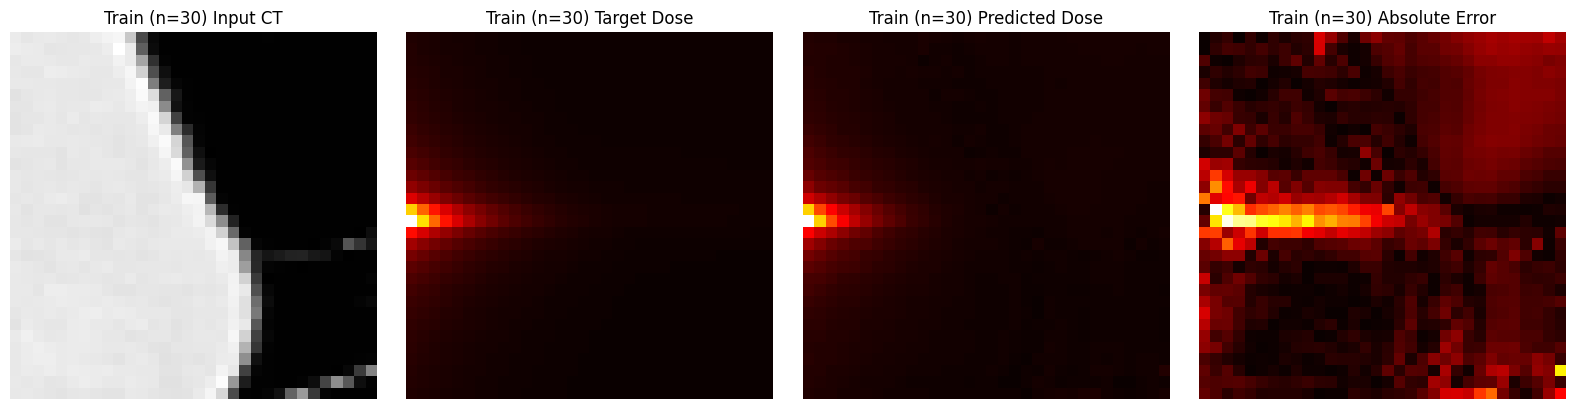

Train best slice index: 16
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_3d_64samples_base24_resampling/test_best_slice_nsteps_30.png


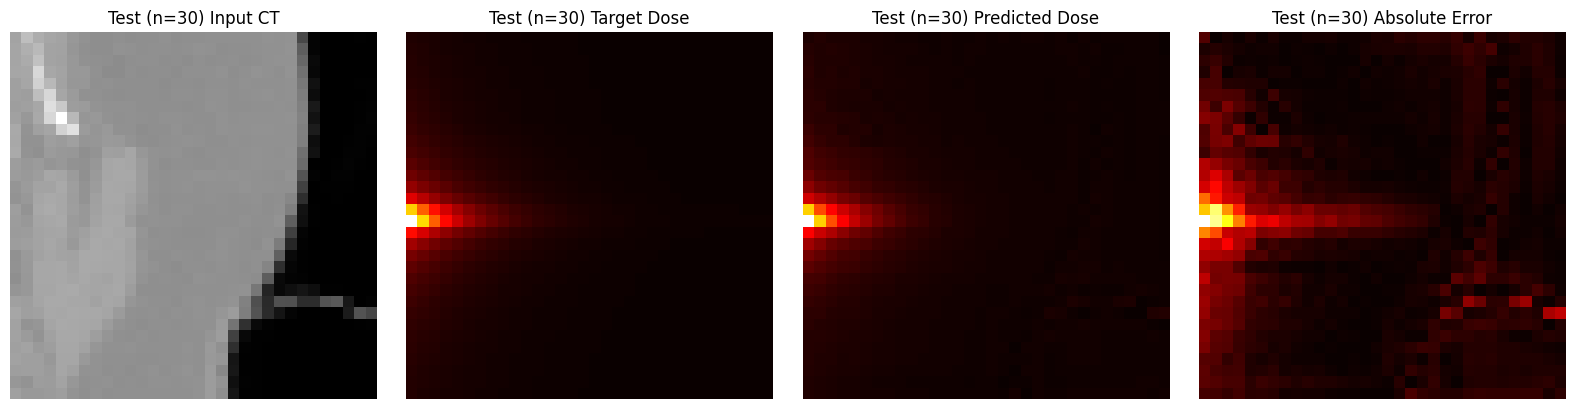

Test best slice index: 16

===== Saving figures for n_steps = 50 =====
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_3d_64samples_base24_resampling/train_best_slice_nsteps_50.png


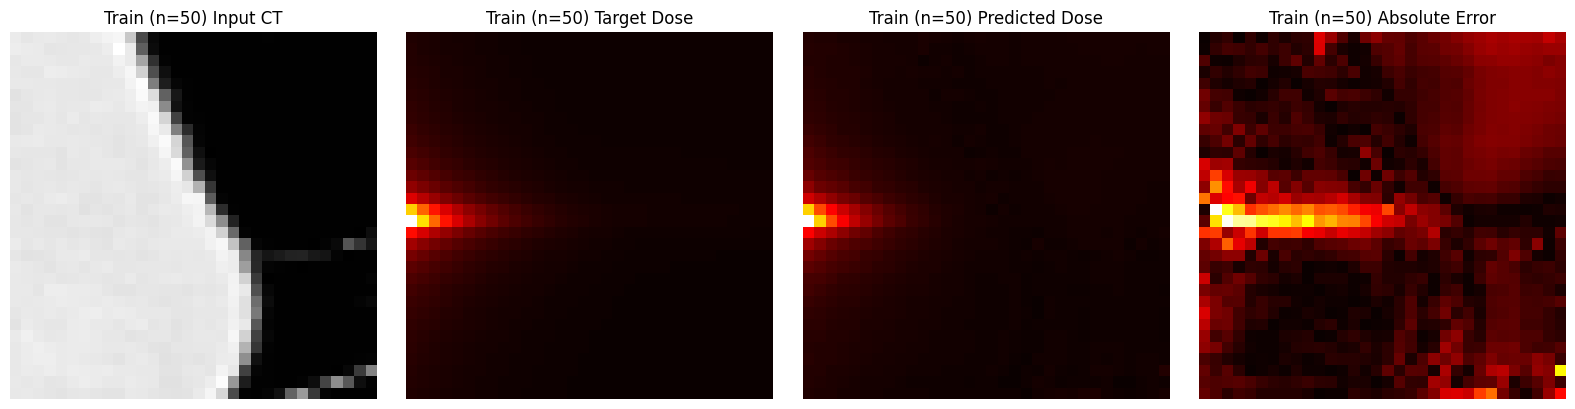

Train best slice index: 16
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_3d_64samples_base24_resampling/test_best_slice_nsteps_50.png


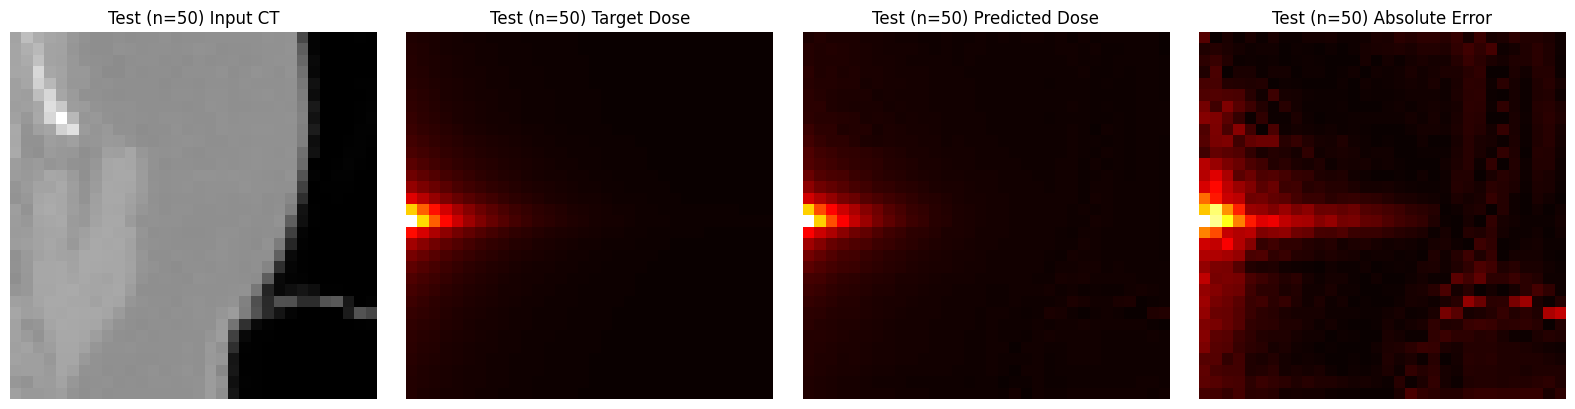

Test best slice index: 16

===== Saving figures for n_steps = 100 =====
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_3d_64samples_base24_resampling/train_best_slice_nsteps_100.png


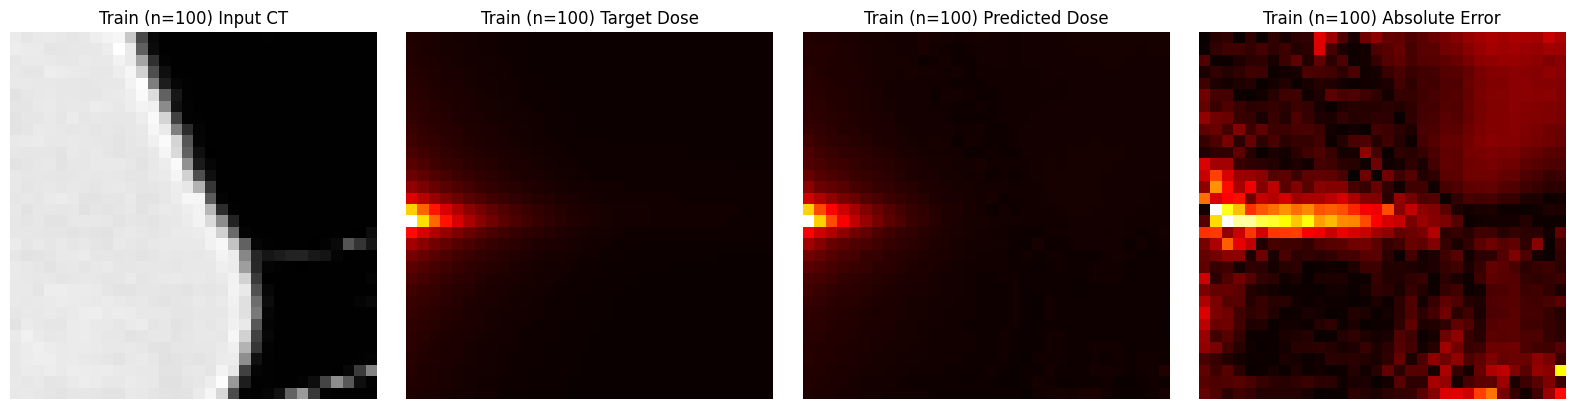

Train best slice index: 16
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_3d_64samples_base24_resampling/test_best_slice_nsteps_100.png


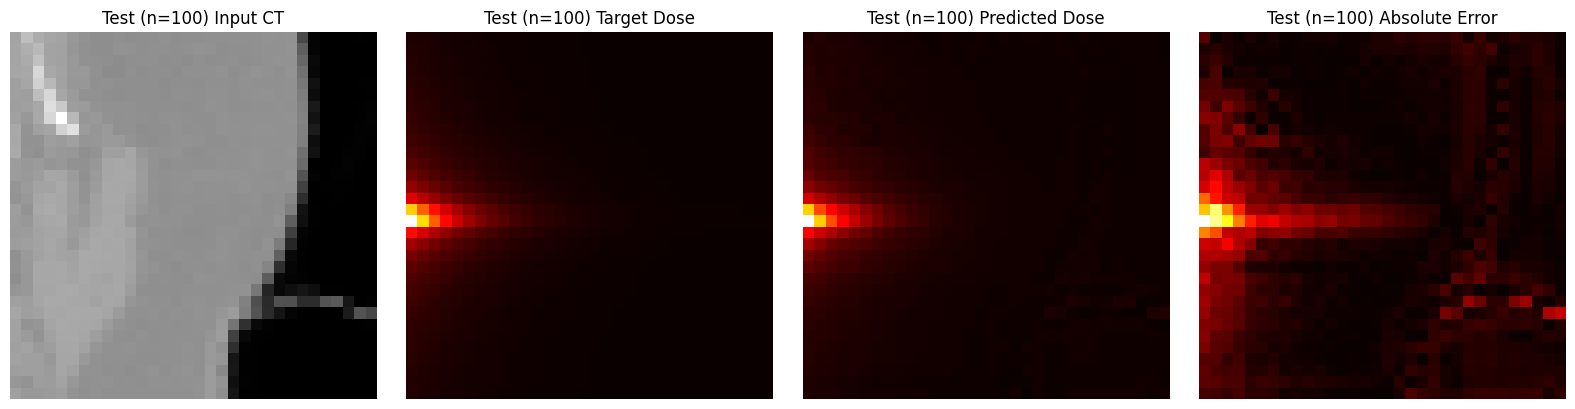

Test best slice index: 16


In [28]:
for n_steps in step_list:
    print(f"\n===== Saving figures for n_steps = {n_steps} =====")

    # train figure
    x0, x1 = next(iter(train_loader_3d))
    x0 = x0.to(device)
    x1 = x1.to(device)

    with torch.no_grad():
        pred = euler_sample_flow_3d(model_3d, x0, n_steps=n_steps)

    x0_np = x0[0, 0].cpu().numpy()
    x1_np = x1[0, 0].cpu().numpy()
    pred_np = pred[0, 0].cpu().numpy()

    train_fig_path = FIG_DIR / f"train_best_slice_nsteps_{n_steps}.png"
    train_idx = save_best_slice_panel_3d(
        x0_np, x1_np, pred_np,
        train_fig_path,
        axis=0,
        prefix=f"Train (n={n_steps}) "
    )
    print("Train best slice index:", train_idx)

    # test figure
    x0, x1 = next(iter(test_loader_3d))
    x0 = x0.to(device)
    x1 = x1.to(device)

    with torch.no_grad():
        pred = euler_sample_flow_3d(model_3d, x0, n_steps=n_steps)

    x0_np = x0[0, 0].cpu().numpy()
    x1_np = x1[0, 0].cpu().numpy()
    pred_np = pred[0, 0].cpu().numpy()

    test_fig_path = FIG_DIR / f"test_best_slice_nsteps_{n_steps}.png"
    test_idx = save_best_slice_panel_3d(
        x0_np, x1_np, pred_np,
        test_fig_path,
        axis=0,
        prefix=f"Test (n={n_steps}) "
    )
    print("Test best slice index:", test_idx)

### 11. Save summary text

In [29]:
summary_path = FIG_DIR / "resampling_summary.txt"

lines = []
lines.append("Re-evaluation of 3D conditional flow checkpoint with higher Euler steps\n")
lines.append(f"Checkpoint: {CKPT_PATH}\n")

for n_steps in step_list:
    lines.append(f"\nEuler steps = {n_steps}")
    lines.append(f"Train MSE = {all_results[n_steps]['train']['mse']:.6f}")
    lines.append(f"Train MAE = {all_results[n_steps]['train']['mae']:.6f}")
    lines.append(f"Test MSE  = {all_results[n_steps]['test']['mse']:.6f}")
    lines.append(f"Test MAE  = {all_results[n_steps]['test']['mae']:.6f}")

summary_text = "\n".join(lines)

with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print("Saved:", summary_path)
print(summary_text)

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_3d_64samples_base24_resampling/resampling_summary.txt
Re-evaluation of 3D conditional flow checkpoint with higher Euler steps

Checkpoint: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/conditional_unet3d_flow_64samples_base24.pt


Euler steps = 30
Train MSE = 0.000545
Train MAE = 0.016592
Test MSE  = 0.000760
Test MAE  = 0.018654

Euler steps = 50
Train MSE = 0.000547
Train MAE = 0.016615
Test MSE  = 0.000760
Test MAE  = 0.018662

Euler steps = 100
Train MSE = 0.000548
Train MAE = 0.016632
Test MSE  = 0.000761
Test MAE  = 0.018669


### 12. Optional quick comparison plot

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_3d_64samples_base24_resampling/mse_vs_euler_steps.png


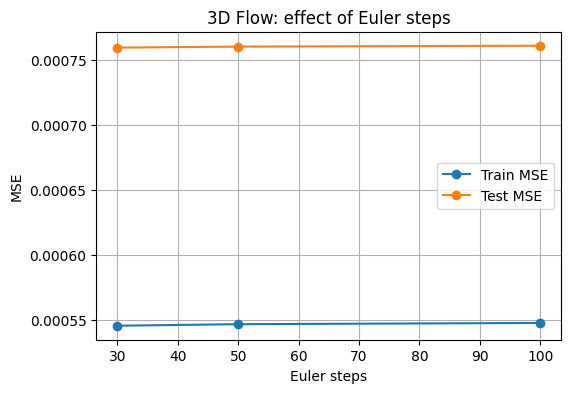

In [30]:
steps = step_list
train_mse = [all_results[s]["train"]["mse"] for s in steps]
test_mse  = [all_results[s]["test"]["mse"] for s in steps]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(steps, train_mse, marker="o", label="Train MSE")
ax.plot(steps, test_mse, marker="o", label="Test MSE")
ax.set_title("3D Flow: effect of Euler steps")
ax.set_xlabel("Euler steps")
ax.set_ylabel("MSE")
ax.grid(True)
ax.legend()

plot_path = FIG_DIR / "mse_vs_euler_steps.png"
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
print("Saved:", plot_path)
plt.show()

## Stronger 3D conditional flow baseline
(64 train / 32 test, base_ch=32)

### 1. Paths

In [31]:
BASE_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose")
SPLIT_DIR = BASE_DIR / "data" / "splits"
CKPT_DIR = BASE_DIR / "outputs" / "checkpoints"
FIG_DIR = BASE_DIR / "outputs" / "figures" / "flow_3d_64samples_base32"

CKPT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

train_manifest_3d = SPLIT_DIR / "train_pairs_3d.json"
test_manifest_3d  = SPLIT_DIR / "test_pairs_3d.json"

print("train manifest:", train_manifest_3d)
print("test manifest :", test_manifest_3d)
print("CKPT_DIR      :", CKPT_DIR)
print("FIG_DIR       :", FIG_DIR)


train manifest: /content/drive/MyDrive/rectified_flow_ct2dose/data/splits/train_pairs_3d.json
test manifest : /content/drive/MyDrive/rectified_flow_ct2dose/data/splits/test_pairs_3d.json
CKPT_DIR      : /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints
FIG_DIR       : /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_3d_64samples_base32


### 2. Dataset

In [32]:
def normalize_ct(x):
    x = np.clip(x, -1024.0, 1500.0)
    x = (x + 1024.0) / (1500.0 + 1024.0)
    return x.astype(np.float32)

class CubePair3DDataset(Dataset):
    def __init__(self, manifest_path, dose_scale=1000.0):
        with open(manifest_path, "r", encoding="utf-8") as f:
            self.records = json.load(f)
        self.dose_scale = dose_scale

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        x0 = np.load(rec["input_path"]).astype(np.float32)
        x1 = np.load(rec["output_path"]).astype(np.float32)

        x0 = normalize_ct(x0)
        x1 = (x1 * self.dose_scale).astype(np.float32)

        x0 = torch.from_numpy(x0).unsqueeze(0)   # (1,D,H,W)
        x1 = torch.from_numpy(x1).unsqueeze(0)   # (1,D,H,W)

        return x0, x1


### 3. Dataloaders

In [33]:
train_dataset_3d = CubePair3DDataset(train_manifest_3d, dose_scale=1000.0)
test_dataset_3d  = CubePair3DDataset(test_manifest_3d, dose_scale=1000.0)

train_subset_3d = Subset(train_dataset_3d, list(range(64)))
test_subset_3d  = Subset(test_dataset_3d, list(range(32)))


train_loader_3d = DataLoader(train_subset_3d, batch_size=2, shuffle=True, num_workers=0)
test_loader_3d  = DataLoader(test_subset_3d, batch_size=2, shuffle=False, num_workers=0)

x0, x1 = train_subset_3d[0]
print("single x0:", x0.shape, x0.dtype, x0.min().item(), x0.max().item())
print("single x1:", x1.shape, x1.dtype, x1.min().item(), x1.max().item())

bx0, bx1 = next(iter(train_loader_3d))
print("batch x0:", bx0.shape)
print("batch x1:", bx1.shape)

single x0: torch.Size([1, 32, 32, 32]) torch.float32 0.0033760373480618 0.8727859258651733
single x1: torch.Size([1, 32, 32, 32]) torch.float32 0.0007880193879827857 2.7264456748962402
batch x0: torch.Size([2, 1, 32, 32, 32])
batch x1: torch.Size([2, 1, 32, 32, 32])


### 4. Model blocks

In [34]:
class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class ConditionalUNetFlow3D(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base_ch=32):
        super().__init__()

        self.enc1 = DoubleConv3D(in_ch, base_ch)
        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv3D(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv3D(base_ch * 2, base_ch * 4)

        self.up2 = nn.ConvTranspose3d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose3d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(base_ch * 2, base_ch)

        self.out_conv = nn.Conv3d(base_ch, out_ch, kernel_size=1)

    def forward(self, xt, x0, t):
        # xt, x0: (B,1,D,H,W)
        # t:      (B,1,1,1,1)
        t_map = t.expand(-1, 1, xt.shape[2], xt.shape[3], xt.shape[4])
        inp = torch.cat([xt, x0, t_map], dim=1)

        e1 = self.enc1(inp)
        e2 = self.enc2(self.pool1(e1))
        b  = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)

### 5. Device, optimizer, flow loss

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model_3d = ConditionalUNetFlow3D(in_ch=3, out_ch=1, base_ch=32).to(device)
optimizer = torch.optim.Adam(model_3d.parameters(), lr=1e-3)

def flow_matching_loss_3d(model, x0, x1):
    B = x0.shape[0]
    t = torch.rand(B, 1, 1, 1, 1, device=x0.device)

    xt = (1.0 - t) * x0 + t * x1
    target_velocity = x1 - x0

    pred_velocity = model(xt, x0, t)
    loss = F.mse_loss(pred_velocity, target_velocity)
    return loss

device: cuda


### 6. Training

In [36]:
num_epochs = 30
train_losses_3d = []

for epoch in range(num_epochs):
    model_3d.train()
    running_loss = 0.0

    for x0, x1 in train_loader_3d:
        x0 = x0.to(device)
        x1 = x1.to(device)

        optimizer.zero_grad()
        loss = flow_matching_loss_3d(model_3d, x0, x1)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader_3d)
    train_losses_3d.append(epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - train loss: {epoch_loss:.6f}")

Epoch 1/30 - train loss: 0.042878
Epoch 2/30 - train loss: 0.013334
Epoch 3/30 - train loss: 0.007259
Epoch 4/30 - train loss: 0.005180
Epoch 5/30 - train loss: 0.005383
Epoch 6/30 - train loss: 0.004780
Epoch 7/30 - train loss: 0.003782
Epoch 8/30 - train loss: 0.004976
Epoch 9/30 - train loss: 0.004230
Epoch 10/30 - train loss: 0.003669
Epoch 11/30 - train loss: 0.003019
Epoch 12/30 - train loss: 0.003051
Epoch 13/30 - train loss: 0.002775
Epoch 14/30 - train loss: 0.001896
Epoch 15/30 - train loss: 0.001954
Epoch 16/30 - train loss: 0.002251
Epoch 17/30 - train loss: 0.002501
Epoch 18/30 - train loss: 0.002754
Epoch 19/30 - train loss: 0.003331
Epoch 20/30 - train loss: 0.002931
Epoch 21/30 - train loss: 0.002337
Epoch 22/30 - train loss: 0.008728
Epoch 23/30 - train loss: 0.002011
Epoch 24/30 - train loss: 0.001555
Epoch 25/30 - train loss: 0.001264
Epoch 26/30 - train loss: 0.001162
Epoch 27/30 - train loss: 0.001127
Epoch 28/30 - train loss: 0.001379
Epoch 29/30 - train loss: 0.0

### 7. Save loss curve

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_3d_64samples_base32/loss_curve_64samples_base32.png


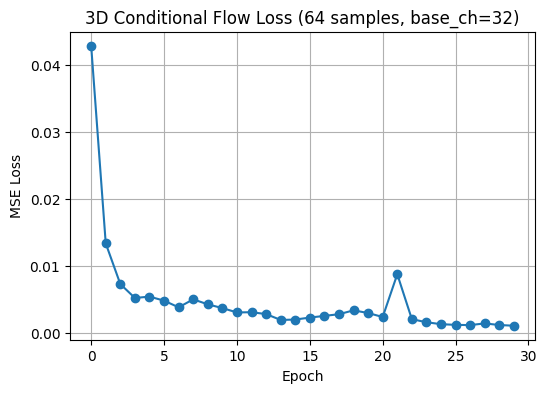

In [37]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(train_losses_3d, marker="o")
ax.set_title("3D Conditional Flow Loss (64 samples, base_ch=32)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.grid(True)

loss_path = FIG_DIR / "loss_curve_64samples_base32.png"
fig.savefig(loss_path, dpi=150, bbox_inches="tight")
print("Saved:", loss_path)
plt.show()

### 8. Euler sampler

In [38]:
@torch.no_grad()
def euler_sample_flow_3d(model, x0, n_steps=30):
    model.eval()
    z = x0.clone()
    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((z.shape[0], 1, 1, 1, 1), k / n_steps, device=z.device)
        v = model(z, x0, t)
        z = z + dt * v

    return z

### 9. Evaluation

In [39]:
@torch.no_grad()
def evaluate_flow_3d(model, loader, device, n_steps=30):
    model.eval()
    total_mse = 0.0
    total_mae = 0.0
    n_batches = 0

    for x0, x1 in loader:
        x0 = x0.to(device)
        x1 = x1.to(device)

        pred = euler_sample_flow_3d(model, x0, n_steps=n_steps)

        mse = F.mse_loss(pred, x1).item()
        mae = F.l1_loss(pred, x1).item()

        total_mse += mse
        total_mae += mae
        n_batches += 1

    return {
        "mse": total_mse / n_batches,
        "mae": total_mae / n_batches
    }

train_metrics_3d = evaluate_flow_3d(model_3d, train_loader_3d, device, n_steps=30)
test_metrics_3d  = evaluate_flow_3d(model_3d, test_loader_3d, device, n_steps=30)

print("Train metrics 3D:", train_metrics_3d)
print("Test metrics 3D :", test_metrics_3d)

Train metrics 3D: {'mse': 0.0028163494207547046, 'mae': 0.025034205871634185}
Test metrics 3D : {'mse': 0.0031016052525956184, 'mae': 0.027186650433577597}


### 10. Best-slice helper

In [40]:
def save_best_slice_panel_3d(x0_np, x1_np, pred_np, save_path, axis=0, prefix=""):
    if axis == 0:
        scores = x1_np.sum(axis=(1, 2))
    elif axis == 1:
        scores = x1_np.sum(axis=(0, 2))
    elif axis == 2:
        scores = x1_np.sum(axis=(0, 1))
    else:
        raise ValueError("axis must be 0, 1, or 2")

    best_idx = int(np.argmax(scores))

    if axis == 0:
        x0_sl = x0_np[best_idx]
        x1_sl = x1_np[best_idx]
        pred_sl = pred_np[best_idx]
    elif axis == 1:
        x0_sl = x0_np[:, best_idx, :]
        x1_sl = x1_np[:, best_idx, :]
        pred_sl = pred_np[:, best_idx, :]
    else:
        x0_sl = x0_np[:, :, best_idx]
        x1_sl = x1_np[:, :, best_idx]
        pred_sl = pred_np[:, :, best_idx]

    err_sl = np.abs(pred_sl - x1_sl)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(x0_sl, cmap="gray")
    axes[0].set_title(f"{prefix}Input CT")
    axes[0].axis("off")

    axes[1].imshow(x1_sl, cmap="hot")
    axes[1].set_title(f"{prefix}Target Dose")
    axes[1].axis("off")

    axes[2].imshow(pred_sl, cmap="hot")
    axes[2].set_title(f"{prefix}Predicted Dose")
    axes[2].axis("off")

    axes[3].imshow(err_sl, cmap="hot")
    axes[3].set_title(f"{prefix}Absolute Error")
    axes[3].axis("off")

    plt.tight_layout()
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print("Saved:", save_path)
    plt.show()

    return best_idx

### 11. Save train best-slice figure

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_3d_64samples_base32/train_best_slice_64samples_base32.png


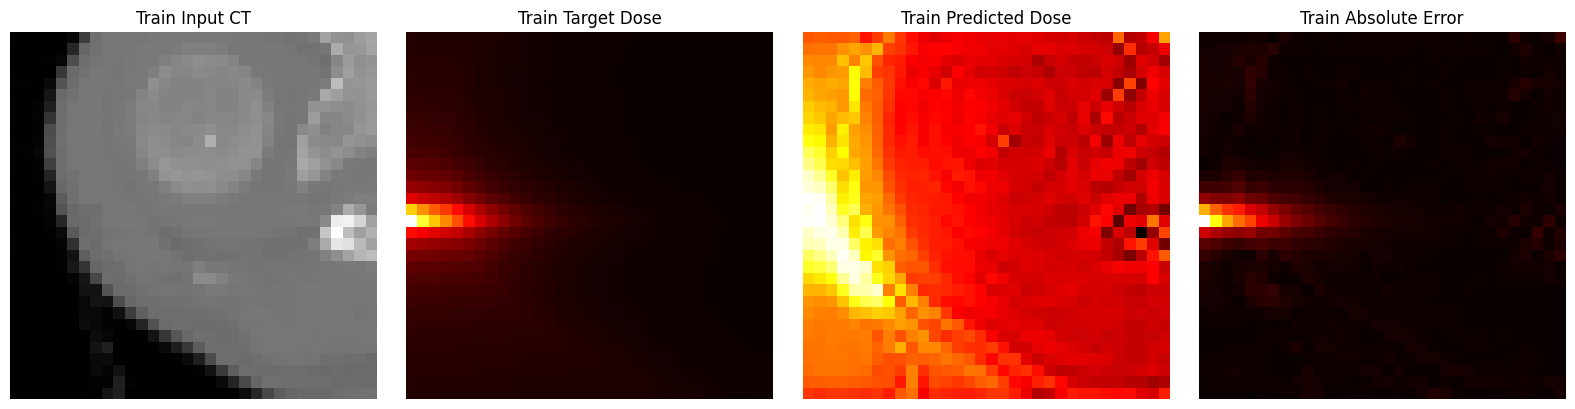

Train best slice index: 16


In [41]:
model_3d.eval()

x0, x1 = next(iter(train_loader_3d))
x0 = x0.to(device)
x1 = x1.to(device)

with torch.no_grad():
    pred = euler_sample_flow_3d(model_3d, x0, n_steps=30)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()

train_fig_path = FIG_DIR / "train_best_slice_64samples_base32.png"
best_idx_train = save_best_slice_panel_3d(
    x0_np, x1_np, pred_np,
    train_fig_path,
    axis=0,
    prefix="Train "
)
print("Train best slice index:", best_idx_train)

### 12. Save test best-slice figure

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_3d_64samples_base32/test_best_slice_64samples_base32.png


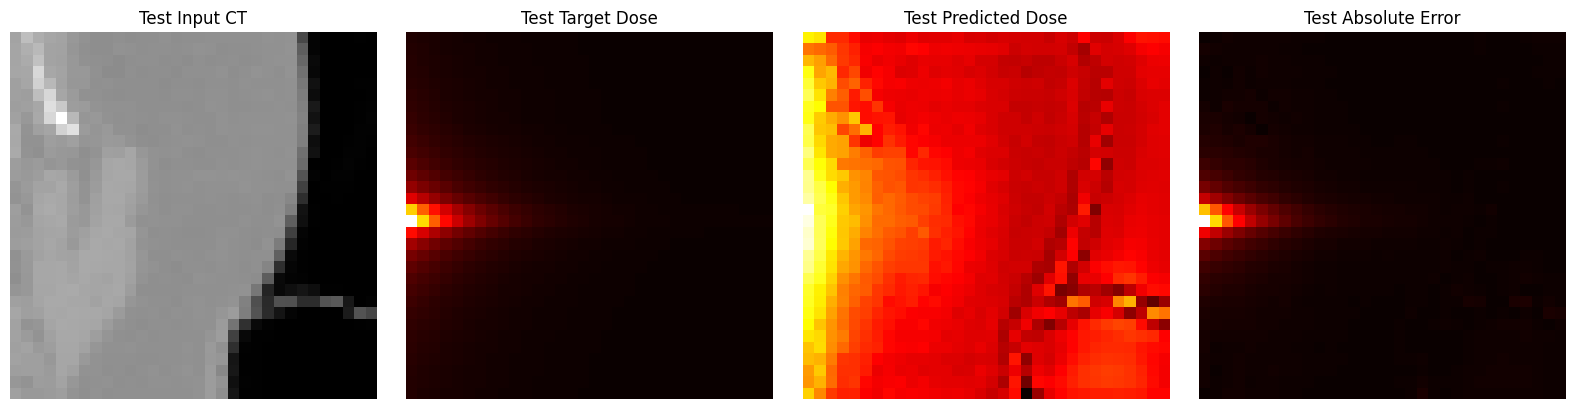

Test best slice index: 16


In [42]:
model_3d.eval()

x0, x1 = next(iter(test_loader_3d))
x0 = x0.to(device)
x1 = x1.to(device)

with torch.no_grad():
    pred = euler_sample_flow_3d(model_3d, x0, n_steps=30)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()

test_fig_path = FIG_DIR / "test_best_slice_64samples_base32.png"
best_idx_test = save_best_slice_panel_3d(
    x0_np, x1_np, pred_np,
    test_fig_path,
    axis=0,
    prefix="Test "
)
print("Test best slice index:", best_idx_test)

### 13. Save checkpoint

In [43]:
ckpt_path = CKPT_DIR / "conditional_unet3d_flow_64samples_base32.pt"

torch.save({
    "model_state_dict": model_3d.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses": train_losses_3d,
    "train_metrics": train_metrics_3d,
    "test_metrics": test_metrics_3d,
    "dose_scale": 1000.0,
    "num_epochs": num_epochs,
    "num_train_samples": 64,
    "num_test_samples": 32,
    "base_ch": 32,
    "n_steps": 30,
}, ckpt_path)

print("Saved checkpoint to:", ckpt_path)

Saved checkpoint to: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/conditional_unet3d_flow_64samples_base32.pt


### 14. Save short summary

In [44]:
summary_path = FIG_DIR / "summary_64samples_base32.txt"

summary_text = f"""
3D conditional flow baseline (64 samples, base_ch=32)

Train subset: 64
Test subset : 32
Epochs      : 30
Dose scale  : 1000.0
Euler steps : 30

Train metrics:
MSE = {train_metrics_3d['mse']:.6f}
MAE = {train_metrics_3d['mae']:.6f}

Test metrics:
MSE = {test_metrics_3d['mse']:.6f}
MAE = {test_metrics_3d['mae']:.6f}
"""

with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print("Saved:", summary_path)
print(summary_text)

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_3d_64samples_base32/summary_64samples_base32.txt

3D conditional flow baseline (64 samples, base_ch=32)

Train subset: 64
Test subset : 32
Epochs      : 30
Dose scale  : 1000.0
Euler steps : 30

Train metrics:
MSE = 0.002816
MAE = 0.025034

Test metrics:
MSE = 0.003102
MAE = 0.027187



## More stable 3D conditional flow baseline
(64 train / 32 test, base_ch=24, batch_size=2
lower LR + longer training)

### 1. Paths

In [45]:
BASE_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose")
SPLIT_DIR = BASE_DIR / "data" / "splits"
CKPT_DIR = BASE_DIR / "outputs" / "checkpoints"
FIG_DIR = BASE_DIR / "outputs" / "figures" / "flow_3d_64samples_base24_lr3e4_ep50"

CKPT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

train_manifest_3d = SPLIT_DIR / "train_pairs_3d.json"
test_manifest_3d  = SPLIT_DIR / "test_pairs_3d.json"

print("train manifest:", train_manifest_3d)
print("test manifest :", test_manifest_3d)
print("CKPT_DIR      :", CKPT_DIR)
print("FIG_DIR       :", FIG_DIR)

train manifest: /content/drive/MyDrive/rectified_flow_ct2dose/data/splits/train_pairs_3d.json
test manifest : /content/drive/MyDrive/rectified_flow_ct2dose/data/splits/test_pairs_3d.json
CKPT_DIR      : /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints
FIG_DIR       : /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_3d_64samples_base24_lr3e4_ep50


### 2. Dataset

In [46]:
def normalize_ct(x):
    x = np.clip(x, -1024.0, 1500.0)
    x = (x + 1024.0) / (1500.0 + 1024.0)
    return x.astype(np.float32)

class CubePair3DDataset(Dataset):
    def __init__(self, manifest_path, dose_scale=1000.0):
        with open(manifest_path, "r", encoding="utf-8") as f:
            self.records = json.load(f)
        self.dose_scale = dose_scale

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        x0 = np.load(rec["input_path"]).astype(np.float32)
        x1 = np.load(rec["output_path"]).astype(np.float32)

        x0 = normalize_ct(x0)
        x1 = (x1 * self.dose_scale).astype(np.float32)

        x0 = torch.from_numpy(x0).unsqueeze(0)   # (1,D,H,W)
        x1 = torch.from_numpy(x1).unsqueeze(0)   # (1,D,H,W)

        return x0, x1

### 3. Dataloaders



In [47]:
train_dataset_3d = CubePair3DDataset(train_manifest_3d, dose_scale=1000.0)
test_dataset_3d  = CubePair3DDataset(test_manifest_3d, dose_scale=1000.0)

train_subset_3d = Subset(train_dataset_3d, list(range(64)))
test_subset_3d  = Subset(test_dataset_3d, list(range(32)))

train_loader_3d = DataLoader(train_subset_3d, batch_size=2, shuffle=True, num_workers=0)
test_loader_3d  = DataLoader(test_subset_3d, batch_size=2, shuffle=False, num_workers=0)

x0, x1 = train_subset_3d[0]
print("single x0:", x0.shape, x0.dtype, x0.min().item(), x0.max().item())
print("single x1:", x1.shape, x1.dtype, x1.min().item(), x1.max().item())

bx0, bx1 = next(iter(train_loader_3d))
print("batch x0:", bx0.shape)
print("batch x1:", bx1.shape)

single x0: torch.Size([1, 32, 32, 32]) torch.float32 0.0033760373480618 0.8727859258651733
single x1: torch.Size([1, 32, 32, 32]) torch.float32 0.0007880193879827857 2.7264456748962402
batch x0: torch.Size([2, 1, 32, 32, 32])
batch x1: torch.Size([2, 1, 32, 32, 32])


### 4. Model blocks

In [48]:
class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class ConditionalUNetFlow3D(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base_ch=24):
        super().__init__()

        self.enc1 = DoubleConv3D(in_ch, base_ch)
        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv3D(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv3D(base_ch * 2, base_ch * 4)

        self.up2 = nn.ConvTranspose3d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose3d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(base_ch * 2, base_ch)

        self.out_conv = nn.Conv3d(base_ch, out_ch, kernel_size=1)

    def forward(self, xt, x0, t):
        t_map = t.expand(-1, 1, xt.shape[2], xt.shape[3], xt.shape[4])
        inp = torch.cat([xt, x0, t_map], dim=1)

        e1 = self.enc1(inp)
        e2 = self.enc2(self.pool1(e1))
        b  = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)

### 5. Device / optimizer / loss

In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model_3d = ConditionalUNetFlow3D(in_ch=3, out_ch=1, base_ch=24).to(device)

# Only lower down the learning rate
optimizer = torch.optim.Adam(model_3d.parameters(), lr=3e-4)

def flow_matching_loss_3d(model, x0, x1):
    B = x0.shape[0]
    t = torch.rand(B, 1, 1, 1, 1, device=x0.device)

    xt = (1.0 - t) * x0 + t * x1
    target_velocity = x1 - x0

    pred_velocity = model(xt, x0, t)
    loss = F.mse_loss(pred_velocity, target_velocity)
    return loss

device: cuda


### 6. Training

In [50]:
num_epochs = 50
train_losses_3d = []

for epoch in range(num_epochs):
    model_3d.train()
    running_loss = 0.0

    for x0, x1 in train_loader_3d:
        x0 = x0.to(device)
        x1 = x1.to(device)

        optimizer.zero_grad()
        loss = flow_matching_loss_3d(model_3d, x0, x1)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model_3d.parameters(), max_norm=1.0)

        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader_3d)
    train_losses_3d.append(epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - train loss: {epoch_loss:.6f}")

Epoch 1/50 - train loss: 0.041677
Epoch 2/50 - train loss: 0.011505
Epoch 3/50 - train loss: 0.006885
Epoch 4/50 - train loss: 0.005261
Epoch 5/50 - train loss: 0.004266
Epoch 6/50 - train loss: 0.004066
Epoch 7/50 - train loss: 0.003644
Epoch 8/50 - train loss: 0.002810
Epoch 9/50 - train loss: 0.002459
Epoch 10/50 - train loss: 0.002323
Epoch 11/50 - train loss: 0.002110
Epoch 12/50 - train loss: 0.001966
Epoch 13/50 - train loss: 0.001693
Epoch 14/50 - train loss: 0.001695
Epoch 15/50 - train loss: 0.001709
Epoch 16/50 - train loss: 0.002239
Epoch 17/50 - train loss: 0.001920
Epoch 18/50 - train loss: 0.001740
Epoch 19/50 - train loss: 0.001300
Epoch 20/50 - train loss: 0.001165
Epoch 21/50 - train loss: 0.001090
Epoch 22/50 - train loss: 0.001026
Epoch 23/50 - train loss: 0.000988
Epoch 24/50 - train loss: 0.001065
Epoch 25/50 - train loss: 0.001176
Epoch 26/50 - train loss: 0.001148
Epoch 27/50 - train loss: 0.001081
Epoch 28/50 - train loss: 0.000859
Epoch 29/50 - train loss: 0.0

### 7. Save loss curve

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_3d_64samples_base24_lr3e4_ep50/loss_curve_64samples_base24_lr3e4_ep50.png


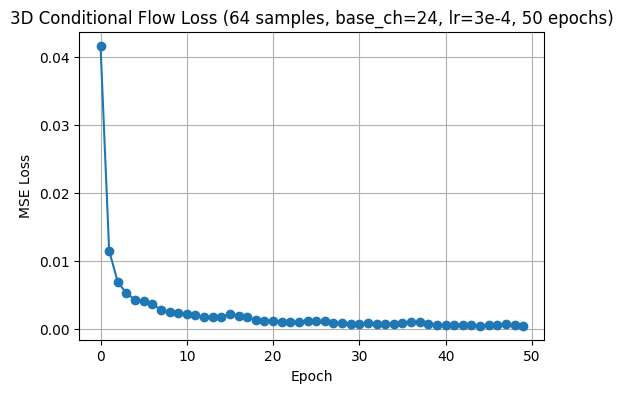

In [51]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(train_losses_3d, marker="o")
ax.set_title("3D Conditional Flow Loss (64 samples, base_ch=24, lr=3e-4, 50 epochs)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.grid(True)

loss_path = FIG_DIR / "loss_curve_64samples_base24_lr3e4_ep50.png"
fig.savefig(loss_path, dpi=150, bbox_inches="tight")
print("Saved:", loss_path)
plt.show()

### 8. Euler sampler

In [52]:
@torch.no_grad()
def euler_sample_flow_3d(model, x0, n_steps=30):
    model.eval()
    z = x0.clone()
    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((z.shape[0], 1, 1, 1, 1), k / n_steps, device=z.device)
        v = model(z, x0, t)
        z = z + dt * v

    return z

### 9. Evaluation

In [53]:
@torch.no_grad()
def evaluate_flow_3d(model, loader, device, n_steps=30):
    model.eval()
    total_mse = 0.0
    total_mae = 0.0
    n_batches = 0

    for x0, x1 in loader:
        x0 = x0.to(device)
        x1 = x1.to(device)

        pred = euler_sample_flow_3d(model, x0, n_steps=n_steps)

        mse = F.mse_loss(pred, x1).item()
        mae = F.l1_loss(pred, x1).item()

        total_mse += mse
        total_mae += mae
        n_batches += 1

    return {
        "mse": total_mse / n_batches,
        "mae": total_mae / n_batches
    }

train_metrics_3d = evaluate_flow_3d(model_3d, train_loader_3d, device, n_steps=30)
test_metrics_3d  = evaluate_flow_3d(model_3d, test_loader_3d, device, n_steps=30)

print("Train metrics 3D:", train_metrics_3d)
print("Test metrics 3D :", test_metrics_3d)

Train metrics 3D: {'mse': 0.00040409567600363516, 'mae': 0.013144405384082347}
Test metrics 3D : {'mse': 0.0005999996519676642, 'mae': 0.01569293742068112}


### 10. Best-slice helper

In [54]:
def save_best_slice_panel_3d(x0_np, x1_np, pred_np, save_path, axis=0, prefix=""):
    if axis == 0:
        scores = x1_np.sum(axis=(1, 2))
    elif axis == 1:
        scores = x1_np.sum(axis=(0, 2))
    elif axis == 2:
        scores = x1_np.sum(axis=(0, 1))
    else:
        raise ValueError("axis must be 0, 1, or 2")

    best_idx = int(np.argmax(scores))

    if axis == 0:
        x0_sl = x0_np[best_idx]
        x1_sl = x1_np[best_idx]
        pred_sl = pred_np[best_idx]
    elif axis == 1:
        x0_sl = x0_np[:, best_idx, :]
        x1_sl = x1_np[:, best_idx, :]
        pred_sl = pred_np[:, best_idx, :]
    else:
        x0_sl = x0_np[:, :, best_idx]
        x1_sl = x1_np[:, :, best_idx]
        pred_sl = pred_np[:, :, best_idx]

    err_sl = np.abs(pred_sl - x1_sl)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(x0_sl, cmap="gray")
    axes[0].set_title(f"{prefix}Input CT")
    axes[0].axis("off")

    axes[1].imshow(x1_sl, cmap="hot")
    axes[1].set_title(f"{prefix}Target Dose")
    axes[1].axis("off")

    axes[2].imshow(pred_sl, cmap="hot")
    axes[2].set_title(f"{prefix}Predicted Dose")
    axes[2].axis("off")

    axes[3].imshow(err_sl, cmap="hot")
    axes[3].set_title(f"{prefix}Absolute Error")
    axes[3].axis("off")

    plt.tight_layout()
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print("Saved:", save_path)
    plt.show()

    return best_idx

### 11. Save train best-slice

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_3d_64samples_base24_lr3e4_ep50/train_best_slice_64samples_base24_lr3e4_ep50.png


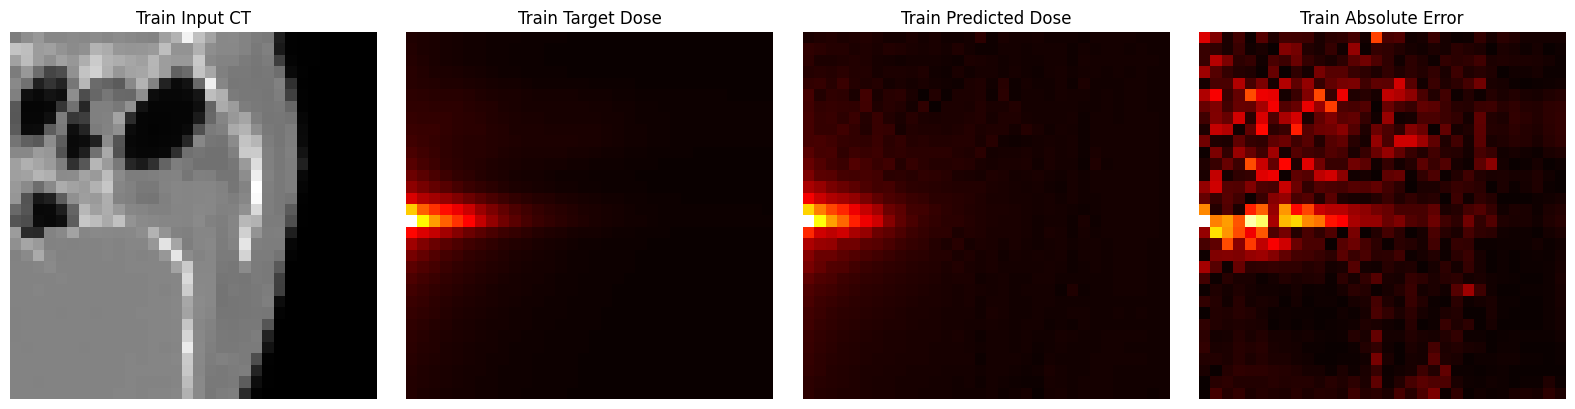

Train best slice index: 16


In [55]:
model_3d.eval()

x0, x1 = next(iter(train_loader_3d))
x0 = x0.to(device)
x1 = x1.to(device)

with torch.no_grad():
    pred = euler_sample_flow_3d(model_3d, x0, n_steps=30)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()

train_fig_path = FIG_DIR / "train_best_slice_64samples_base24_lr3e4_ep50.png"
best_idx_train = save_best_slice_panel_3d(
    x0_np, x1_np, pred_np,
    train_fig_path,
    axis=0,
    prefix="Train "
)
print("Train best slice index:", best_idx_train)

### 12. Save test best-slice

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_3d_64samples_base24_lr3e4_ep50/test_best_slice_64samples_base24_lr3e4_ep50.png


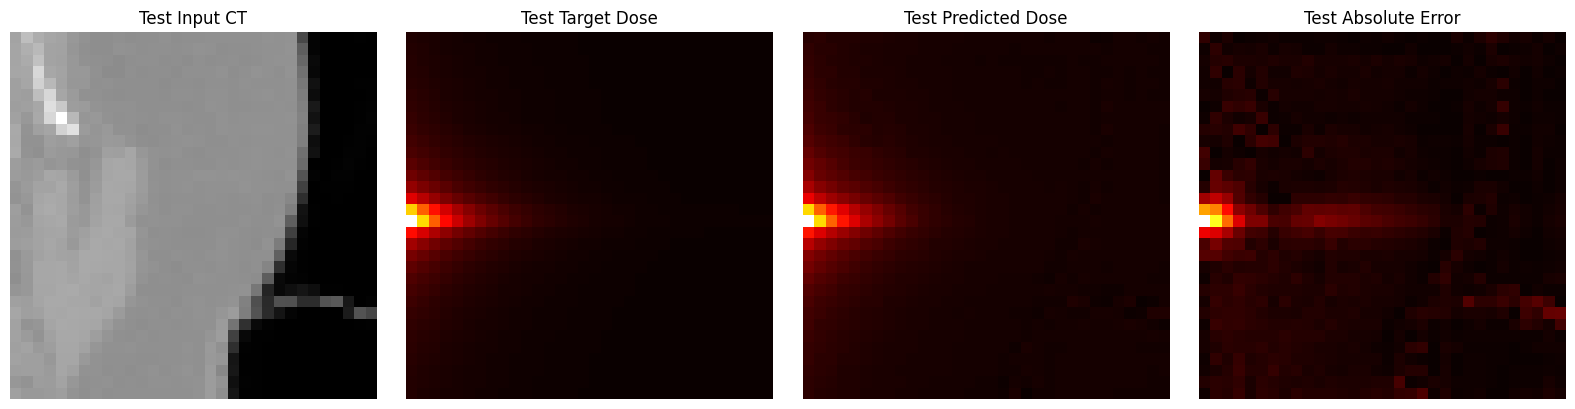

Test best slice index: 16


In [56]:
model_3d.eval()

x0, x1 = next(iter(test_loader_3d))
x0 = x0.to(device)
x1 = x1.to(device)

with torch.no_grad():
    pred = euler_sample_flow_3d(model_3d, x0, n_steps=30)

x0_np = x0[0, 0].cpu().numpy()
x1_np = x1[0, 0].cpu().numpy()
pred_np = pred[0, 0].cpu().numpy()

test_fig_path = FIG_DIR / "test_best_slice_64samples_base24_lr3e4_ep50.png"
best_idx_test = save_best_slice_panel_3d(
    x0_np, x1_np, pred_np,
    test_fig_path,
    axis=0,
    prefix="Test "
)
print("Test best slice index:", best_idx_test)

### 13. Save checkpoint

In [57]:
ckpt_path = CKPT_DIR / "conditional_unet3d_flow_64samples_base24_lr3e4_ep50.pt"

torch.save({
    "model_state_dict": model_3d.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses": train_losses_3d,
    "train_metrics": train_metrics_3d,
    "test_metrics": test_metrics_3d,
    "dose_scale": 1000.0,
    "num_epochs": num_epochs,
    "num_train_samples": 64,
    "num_test_samples": 32,
    "base_ch": 24,
    "batch_size": 2,
    "lr": 3e-4,
    "n_steps": 30,
}, ckpt_path)

print("Saved checkpoint to:", ckpt_path)

Saved checkpoint to: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/conditional_unet3d_flow_64samples_base24_lr3e4_ep50.pt


### 14. Save summary

In [58]:
summary_path = FIG_DIR / "summary_64samples_base24_lr3e4_ep50.txt"

summary_text = f"""
3D conditional flow baseline (64 samples, base_ch=24, lr=3e-4, 50 epochs)

Train subset: 64
Test subset : 32
Epochs      : 50
Dose scale  : 1000.0
Euler steps : 30
Batch size  : 2
Learning rt : 3e-4

Train metrics:
MSE = {train_metrics_3d['mse']:.6f}
MAE = {train_metrics_3d['mae']:.6f}

Test metrics:
MSE = {test_metrics_3d['mse']:.6f}
MAE = {test_metrics_3d['mae']:.6f}
"""

with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print("Saved:", summary_path)
print(summary_text)

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/figures/flow_3d_64samples_base24_lr3e4_ep50/summary_64samples_base24_lr3e4_ep50.txt

3D conditional flow baseline (64 samples, base_ch=24, lr=3e-4, 50 epochs)

Train subset: 64
Test subset : 32
Epochs      : 50
Dose scale  : 1000.0
Euler steps : 30
Batch size  : 2
Learning rt : 3e-4

Train metrics:
MSE = 0.000404
MAE = 0.013144

Test metrics:
MSE = 0.000600
MAE = 0.015693

